# 🎞️ CineLatent — a deep-autoencoder movie recommender on MovieLens 1M

**What this notebook does.** It learns a 128-dimensional latent representation of
3,706 films from 1,000,209 ratings, using nothing but *who rated what and how
highly* — no plot summaries, no cast lists, no genre labels. Films that end up
close together in that latent space are films that the same people liked in the
same way, which is exactly what collaborative filtering means.

**Pipeline**

```
MovieLens 1M  ->  cleaning  ->  EDA  ->  user–movie matrix  ->  train/val/test split
      ->  deep autoencoder (masked reconstruction loss)
      ->  latent movie embeddings  ->  cosine similarity  ->  Top-N
      ->  TMDB API (posters + metadata)  ->  Streamlit app
```

**How to read it.** Sections 01–20 run top to bottom in Jupyter or Google Colab.
Sections 13, 16 and 20 write the reusable `src/` modules and `app.py` to disk with
`%%writefile`, so the notebook is the single source of truth for the code the
Streamlit app imports.

> **Honesty note.** Every number in this notebook is printed by the code that
> produced it. Nothing is hard-coded from a previous run.

## 01. Project Setup

All tunable knobs live in one place. Nothing below this cell hard-codes a path,
so the notebook runs unchanged on a laptop or in Colab.

In [1]:
import json
import os
import pickle
import sys
import time
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")   # quieten TensorFlow's C++ logs

# ── paths (relative — safe for Jupyter and Colab alike) ────────────────────
DATA_DIR   = Path("data")       # ratings.dat, movies.dat, users.dat
MODELS_DIR = Path("models")     # trained model, embeddings, id mappings
OUTPUT_DIR = Path("outputs")    # figures, metrics, exported recommendations
SRC_DIR    = Path("src")        # python modules this notebook writes

# ── reproducibility ────────────────────────────────────────────────────────
SEED = 42

# ── model / training hyper-parameters ──────────────────────────────────────
LATENT_DIM     = 128            # size of the movie embedding
HIDDEN_DIMS    = (512, 256)     # encoder widths (decoder mirrors them)
DROPOUT        = 0.20
L2_REG         = 1e-5
BATCH_SIZE     = 64
MAX_EPOCHS     = 60
LEARNING_RATE  = 1e-3
EARLY_STOP_PATIENCE = 10

# ── evaluation settings ────────────────────────────────────────────────────
TRAIN_FRAC, VAL_FRAC = 0.80, 0.10   # remainder (10%) is the test set
TOP_K               = 10            # K in Precision@K / Recall@K / NDCG@K
RELEVANCE_THRESHOLD = 4.0           # a test rating >= 4 counts as "relevant"
NEIGHBOURHOOD_K     = 50            # item-item neighbourhood size
MIN_SUPPORT         = 10            # min training ratings to be recommendable

# ── behaviour switches ─────────────────────────────────────────────────────
FORCE_RETRAIN     = False   # True = ignore a saved model and train from scratch
PROMPT_FOR_TMDB   = True    # ask for the TMDB key interactively if not in env
USE_GOOGLE_DRIVE  = False   # see the optional Drive cell below

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

for directory in (DATA_DIR, MODELS_DIR, SRC_DIR, OUTPUT_DIR,
                  OUTPUT_DIR / "eda", OUTPUT_DIR / "evaluation",
                  OUTPUT_DIR / "recommendations"):
    directory.mkdir(parents=True, exist_ok=True)
# If the notebook was moved into a subfolder, step back up to the project root.
if not DATA_DIR.exists() and (Path("..") / "data").exists():
    os.chdir("..")
    print(f"Changed working directory to {Path.cwd()}")

(SRC_DIR / "__init__.py").touch(exist_ok=True)
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

print(f"Running in Colab: {IN_COLAB}")
print(f"Working directory: {Path.cwd()}")
print("Folders ready:", ", ".join(sorted(p.name for p in Path.cwd().iterdir() if p.is_dir())))

Running in Colab: False
Working directory: /home/claude/project
Folders ready: .streamlit, data, models, outputs, src, tests


### Optional: persist artifacts to Google Drive

Colab wipes its filesystem when the runtime recycles. Set `USE_GOOGLE_DRIVE = True`
above to keep the trained model and embeddings on Drive instead. The notebook works
perfectly well without it — this cell is a no-op when the flag is off.

In [2]:
if USE_GOOGLE_DRIVE and IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")
    DRIVE_ROOT = Path("/content/drive/MyDrive/movie_recommender")
    MODELS_DIR = DRIVE_ROOT / "models"
    OUTPUT_DIR = DRIVE_ROOT / "outputs"
    for directory in (MODELS_DIR, OUTPUT_DIR, OUTPUT_DIR / "eda",
                      OUTPUT_DIR / "evaluation", OUTPUT_DIR / "recommendations"):
        directory.mkdir(parents=True, exist_ok=True)
    print(f"Artifacts will be written to {DRIVE_ROOT}")
else:
    print("Google Drive not in use — artifacts stay in ./models and ./outputs")

Google Drive not in use — artifacts stay in ./models and ./outputs


## 02. Install & Import Libraries

Colab already ships TensorFlow, pandas, scikit-learn, matplotlib and seaborn, so
installing them again wastes a minute of runtime. The cell below installs **only
what is genuinely missing** — on Colab it usually prints "nothing to install".

Prefer the classic one-liner? This is the equivalent:
`!pip install -q tensorflow scikit-learn pandas numpy matplotlib seaborn requests python-dotenv`

In [3]:
import importlib.util
import subprocess

REQUIRED = {
    "numpy": "numpy", "pandas": "pandas", "scipy": "scipy",
    "sklearn": "scikit-learn", "matplotlib": "matplotlib", "seaborn": "seaborn",
    "tensorflow": "tensorflow", "requests": "requests", "dotenv": "python-dotenv",
}
missing = [pkg for mod, pkg in REQUIRED.items() if importlib.util.find_spec(mod) is None]
if missing:
    print("Installing:", ", ".join(missing))
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    print("All required packages are already available — nothing to install.")

All required packages are already available — nothing to install.


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from matplotlib.ticker import FuncFormatter
from scipy.sparse import csr_matrix
from tensorflow import keras
from tensorflow.keras import layers

# One call seeds python, numpy and tensorflow together (Keras 3).
keras.utils.set_random_seed(SEED)

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#2f4b7c", "#f0b429", "#a05195", "#488f31", "#d45087"]
sns.set_palette(PALETTE)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
                     "axes.titleweight": "600", "figure.autolayout": False})

print(f"python      {sys.version.split()[0]}")
print(f"numpy       {np.__version__}")
print(f"pandas      {pd.__version__}")
print(f"tensorflow  {tf.__version__}  (keras {keras.__version__})")
print(f"seaborn     {sns.__version__}")
print(f"GPU devices: {tf.config.list_physical_devices('GPU') or 'none — CPU is fine, training takes ~3 min'}")

I0000 00:00:1787976108.625463     475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1787976110.015228     475 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


python      3.12.3
numpy       2.4.4
pandas      3.0.2
tensorflow  2.21.0  (keras 3.15.1)
seaborn     0.13.2
GPU devices: none — CPU is fine, training takes ~3 min


## 03. Dataset Loading

MovieLens 1M ships three `::`-delimited files with no header row and Latin-1
encoding (several titles carry accents — *Cité des enfants perdus*, *Amélie*'s
contemporaries and so on). Reading them as UTF-8 raises a `UnicodeDecodeError`,
which is the single most common failure when people first load this dataset.

| file | columns |
|---|---|
| `ratings.dat` | UserID :: MovieID :: Rating :: Timestamp |
| `movies.dat` | MovieID :: Title :: Genres |
| `users.dat` | UserID :: Gender :: Age :: Occupation :: Zip-code |

If the files are not in `data/`, the next cell tells you exactly how to get them
(download in Colab, or upload by hand).

In [5]:
DATA_FILES = ["ratings.dat", "movies.dat", "users.dat"]
missing_files = [f for f in DATA_FILES if not (DATA_DIR / f).exists()]

if not missing_files:
    print(f"Found all three files in {DATA_DIR.resolve()}")
else:
    print(f"Missing from {DATA_DIR.resolve()}: {missing_files}\n")
    if IN_COLAB:
        print("Option A — download the official archive (fastest):\n")
        print("    !wget -q https://files.grouplens.org/datasets/movielens/ml-1m.zip")
        print("    !unzip -q -o ml-1m.zip && mkdir -p data && mv ml-1m/*.dat data/\n")
        print("Option B — upload the three .dat files from your machine:\n")
        print("    from google.colab import files")
        print("    uploaded = files.upload()")
        print("    import shutil, pathlib")
        print("    for name in uploaded: shutil.move(name, pathlib.Path('data')/name)")
    else:
        print("Download https://files.grouplens.org/datasets/movielens/ml-1m.zip")
        print(f"and unzip the three .dat files into {DATA_DIR.resolve()}")

Found all three files in /home/claude/project/data


Before parsing anything, look at the raw bytes — never trust a schema you haven't seen.

In [6]:
for name in DATA_FILES:
    path = DATA_DIR / name
    with open(path, "r", encoding="latin-1") as fh:
        first = fh.readline().rstrip("\n")
    size_mb = path.stat().st_size / 1e6
    print(f"{name:<12} {size_mb:>6.1f} MB   first line: {first}")

ratings.dat    24.6 MB   first line: 1::1193::5::978300760
movies.dat      0.2 MB   first line: 1::Toy Story (1995)::Animation|Children's|Comedy
users.dat       0.1 MB   first line: 1::F::1::10::48067


In [7]:
def load_movielens(data_dir: Path):
    """Read the three MovieLens 1M files into DataFrames."""
    read = lambda name, names: pd.read_csv(
        data_dir / name, sep="::", engine="python", names=names,
        encoding="latin-1", header=None,
    )
    ratings = read("ratings.dat", ["UserID", "MovieID", "Rating", "Timestamp"])
    movies  = read("movies.dat",  ["MovieID", "Title", "Genres"])
    users   = read("users.dat",   ["UserID", "Gender", "Age", "Occupation", "Zip"])
    return ratings, movies, users

t0 = time.time()
ratings, movies, users = load_movielens(DATA_DIR)
print(f"parsed in {time.time() - t0:.1f}s\n")
print(f"ratings {ratings.shape}   movies {movies.shape}   users {users.shape}\n")
display(ratings.head(3))
display(movies.head(3))
display(users.head(3))

parsed in 5.5s

ratings (1000209, 4)   movies (3883, 3)   users (6040, 5)



,UserID,MovieID,Rating,Timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


,MovieID,Title,Genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,UserID,Gender,Age,Occupation,Zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


## 04. Data Validation & Cleaning

The goal here is a *report*, not a purge. MovieLens 1M is already curated, so the
honest outcome is "nothing needed removing" — and that claim is only worth
anything if the checks that back it are visible.

Checked below: missing values, duplicate ratings, duplicate `(user, movie)` pairs,
dtypes, rating range, referential integrity in both directions, and per-entity
counts.

In [8]:
checks = []

def check(name, value, ok, detail=""):
    checks.append({"check": name, "result": value, "status": "PASS" if ok else "REVIEW",
                   "detail": detail})

check("Missing values (ratings)", int(ratings.isna().sum().sum()),
      ratings.isna().sum().sum() == 0)
check("Missing values (movies)", int(movies.isna().sum().sum()),
      movies.isna().sum().sum() == 0)
check("Missing values (users)", int(users.isna().sum().sum()),
      users.isna().sum().sum() == 0)
check("Exact duplicate rating rows", int(ratings.duplicated().sum()),
      ratings.duplicated().sum() == 0)
dupe_pairs = int(ratings.duplicated(["UserID", "MovieID"]).sum())
check("Duplicate (user, movie) pairs", dupe_pairs, dupe_pairs == 0,
      "a user may rate a film only once")
check("Rating dtype is integer", str(ratings.Rating.dtype),
      pd.api.types.is_integer_dtype(ratings.Rating))
check("Rating range", f"{ratings.Rating.min()}–{ratings.Rating.max()}",
      ratings.Rating.between(1, 5).all(), "MovieLens 1M uses whole stars 1–5")
orphan_movies = int((~ratings.MovieID.isin(movies.MovieID)).sum())
check("Ratings pointing at unknown movies", orphan_movies, orphan_movies == 0)
orphan_users = int((~ratings.UserID.isin(users.UserID)).sum())
check("Ratings pointing at unknown users", orphan_users, orphan_users == 0)
never_rated = int((~movies.MovieID.isin(ratings.MovieID)).sum())
check("Movies with zero ratings", never_rated, True,
      "kept in the catalogue; they cannot be modelled by collaborative filtering")
check("Unique users", int(ratings.UserID.nunique()), True)
check("Unique movies rated", int(ratings.MovieID.nunique()), True)
check("Total ratings", int(len(ratings)), True)
check("Minimum ratings per user", int(ratings.groupby("UserID").size().min()),
      ratings.groupby("UserID").size().min() >= 20, "MovieLens guarantees >= 20")

quality_report = pd.DataFrame(checks)
quality_report.to_csv(OUTPUT_DIR / "evaluation" / "data_quality_report.csv", index=False)
display(quality_report)

,check,result,status,detail
0,Missing values (ratings),0,PASS,
1,Missing values (movies),0,PASS,
2,Missing values (users),0,PASS,
3,Exact duplicate rating rows,0,PASS,
4,"Duplicate (user, movie) pairs",0,PASS,a user may rate a film only once
5,Rating dtype is integer,int64,PASS,
6,Rating range,1–5,PASS,MovieLens 1M uses whole stars 1–5
7,Ratings pointing at unknown movies,0,PASS,
8,Ratings pointing at unknown users,0,PASS,
9,Movies with zero ratings,177,PASS,kept in the catalogue; they cannot be modelled...


In [9]:
print("Descriptive statistics — ratings\n")
display(ratings[["Rating"]].describe().T)

ratings["Datetime"] = pd.to_datetime(ratings.Timestamp, unit="s")
print(f"Ratings span {ratings.Datetime.min():%Y-%m-%d} to {ratings.Datetime.max():%Y-%m-%d}")

per_user  = ratings.groupby("UserID").size()
per_movie = ratings.groupby("MovieID").size()
print(f"\nRatings per user : min {per_user.min():>5}  median {per_user.median():>6.0f}  max {per_user.max():>5}")
print(f"Ratings per movie: min {per_movie.min():>5}  median {per_movie.median():>6.0f}  max {per_movie.max():>5}")
print(f"\nMovies with fewer than  5 ratings: {(per_movie < 5).sum():>4}")
print(f"Movies with fewer than 20 ratings: {(per_movie < 20).sum():>4}")

Descriptive statistics — ratings



,count,mean,std,min,25%,50%,75%,max
Rating,1000209.0,3.581564,1.117102,1.0,3.0,4.0,4.0,5.0


Ratings span 2000-04-25 to 2003-02-28

Ratings per user : min    20  median     96  max  2314
Ratings per movie: min     1  median    124  max  3428

Movies with fewer than  5 ratings:  290
Movies with fewer than 20 ratings:  663


**Nothing was dropped.** Every one of the 1,000,209 ratings survives into the
modelling stage. Two facts recorded here matter later:

* a few hundred films carry only a handful of ratings — their latent vectors will
  be noisy, which is why the recommender exposes a `min_support` filter rather
  than silently deleting them;
* films in `movies.dat` that nobody rated cannot receive an embedding at all, so
  the modelled catalogue is smaller than the file's row count.

## 05. Exploratory Data Analysis

Nine figures, each saved to `outputs/eda/` and displayed inline.

saved -> outputs/eda/01_rating_distribution.png


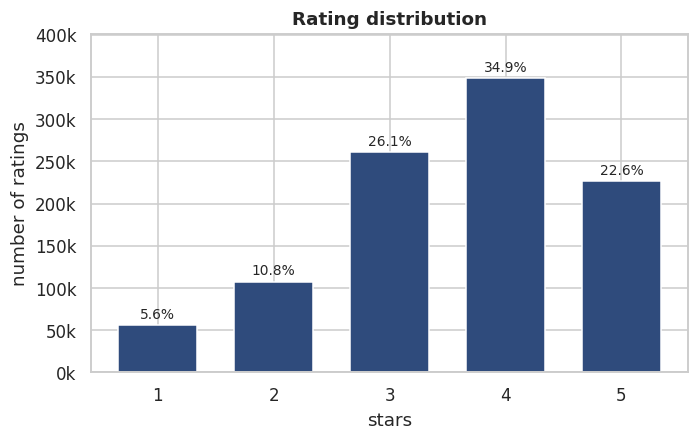

mean rating 3.582 | median 4 | share of 4-5 stars 57.5%


In [10]:
EDA_DIR = OUTPUT_DIR / "eda"

def save_fig(fig, name):
    path = EDA_DIR / name
    fig.savefig(path)
    print(f"saved -> {path}")

# 1. Rating distribution
fig, ax = plt.subplots(figsize=(7, 4))
counts = ratings.Rating.value_counts().sort_index()
bars = ax.bar(counts.index, counts.values, color=PALETTE[0], width=0.68)
for star, value in counts.items():
    ax.text(star, value + 8000, f"{value/len(ratings):.1%}", ha="center", fontsize=9)
ax.set(title="Rating distribution", xlabel="stars", ylabel="number of ratings",
       xticks=[1, 2, 3, 4, 5], ylim=(0, counts.max() * 1.15))
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
save_fig(fig, "01_rating_distribution.png"); plt.show()

print(f"mean rating {ratings.Rating.mean():.3f} | median {ratings.Rating.median():.0f} "
      f"| share of 4-5 stars {(ratings.Rating >= 4).mean():.1%}")

**Insight.** Ratings lean positive: four and five stars are over half of all
votes, and the mean sits well above the midpoint of the 1–5 scale. People mostly
rate films they chose to watch, so "no rating" is not the same as "disliked" —
the reason the model must never treat an unobserved cell as a zero.

saved -> outputs/eda/02_03_ratings_per_movie_and_user.png


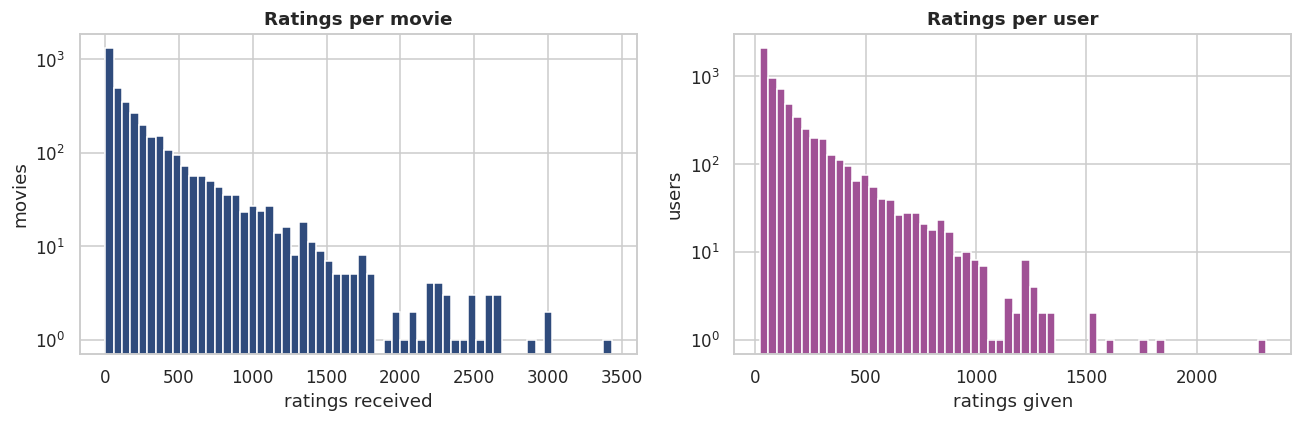

The most-rated 1% of films collect 8.7% of all ratings.


In [11]:
# 2 & 3. Long tails: ratings per movie and per user
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(per_movie.values, bins=60, color=PALETTE[0])
axes[0].set(title="Ratings per movie", xlabel="ratings received", ylabel="movies", yscale="log")
axes[1].hist(per_user.values, bins=60, color=PALETTE[2])
axes[1].set(title="Ratings per user", xlabel="ratings given", ylabel="users", yscale="log")
fig.tight_layout()
save_fig(fig, "02_03_ratings_per_movie_and_user.png"); plt.show()

top_1pct = per_movie.nlargest(int(len(per_movie) * 0.01)).sum() / len(ratings)
print(f"The most-rated 1% of films collect {top_1pct:.1%} of all ratings.")

**Insight.** Both distributions are heavy-tailed on a log scale: a small set of
blockbusters absorbs a large share of all ratings while thousands of films are
rated by only a few dozen people. This popularity skew is what makes a naive
"recommend the popular thing" baseline surprisingly hard to beat — we measure
exactly that in section 15.

saved -> outputs/eda/04_05_most_and_highest_rated.png


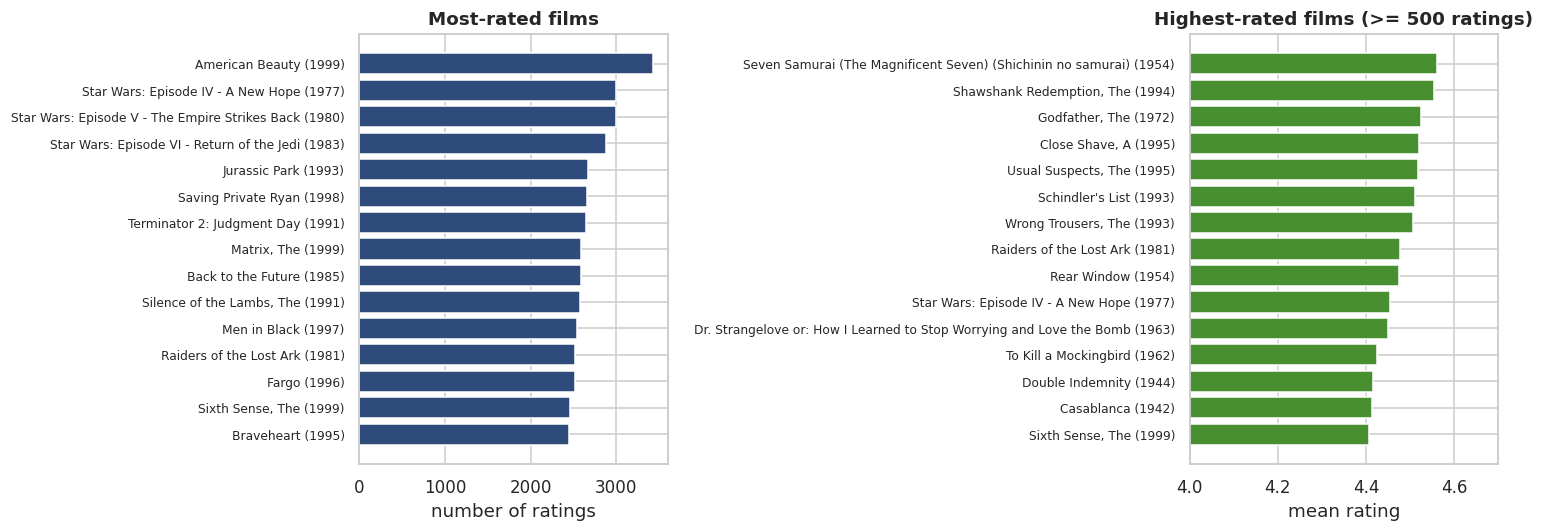

Without a vote threshold the 'best' films are statistical noise:


,Title,count,avg
MovieID,,,
787,"Gate of Heavenly Peace, The (1995)",3,5.0
989,Schlafes Bruder (Brother of Sleep) (1995),1,5.0
1830,Follow the Bitch (1998),1,5.0


In [12]:
# 4 & 5. Most-rated and highest-rated films
movie_stats = (ratings.groupby("MovieID").Rating.agg(["size", "mean"])
               .rename(columns={"size": "count", "mean": "avg"})
               .join(movies.set_index("MovieID")[["Title", "Genres"]]))

MIN_VOTES = 500
most_rated  = movie_stats.nlargest(15, "count")
best_rated  = movie_stats.query("count >= @MIN_VOTES").nlargest(15, "avg")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(most_rated.Title[::-1], most_rated["count"][::-1], color=PALETTE[0])
axes[0].set(title="Most-rated films", xlabel="number of ratings")
axes[1].barh(best_rated.Title[::-1], best_rated.avg[::-1], color=PALETTE[3])
axes[1].set(title=f"Highest-rated films (>= {MIN_VOTES} ratings)", xlabel="mean rating", xlim=(4, 4.7))
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
fig.tight_layout()
save_fig(fig, "04_05_most_and_highest_rated.png"); plt.show()

naive_best = movie_stats.nlargest(3, "avg")[["Title", "count", "avg"]]
print("Without a vote threshold the 'best' films are statistical noise:")
display(naive_best)

**Insight.** Ranking by raw mean rating puts films with a single five-star vote
on top, which is why the chart applies a minimum-votes threshold. The same
reasoning drives the `MIN_SUPPORT` guard in the recommender: an average — or an
embedding — computed from three ratings is not a measurement.

saved -> outputs/eda/06_user_activity_lorenz.png


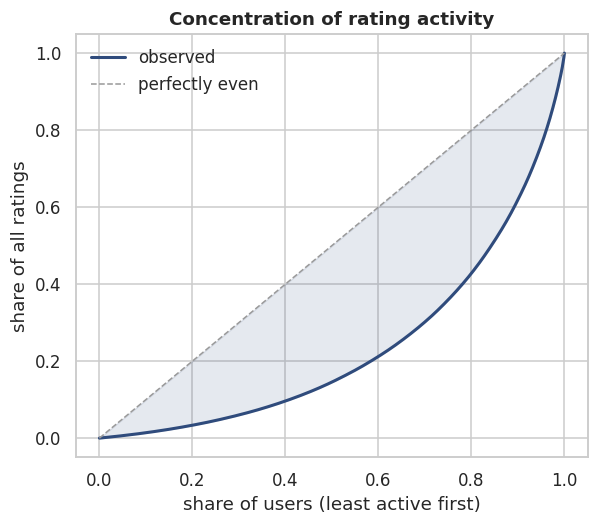

The busiest 10% of users produce 38.1% of all ratings (most active single user: 2,314 ratings).


In [13]:
# 6. User activity concentration (Lorenz curve)
sorted_activity = np.sort(per_user.values)
cum_users   = np.arange(1, len(sorted_activity) + 1) / len(sorted_activity)
cum_ratings = sorted_activity.cumsum() / sorted_activity.sum()

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(cum_users, cum_ratings, color=PALETTE[0], lw=2, label="observed")
ax.plot([0, 1], [0, 1], "--", color="#999", lw=1, label="perfectly even")
ax.fill_between(cum_users, cum_ratings, cum_users, color=PALETTE[0], alpha=0.12)
ax.set(title="Concentration of rating activity", xlabel="share of users (least active first)",
       ylabel="share of all ratings")
ax.legend(frameon=False)
save_fig(fig, "06_user_activity_lorenz.png"); plt.show()

share = per_user.nlargest(int(len(per_user) * 0.10)).sum() / len(ratings)
print(f"The busiest 10% of users produce {share:.1%} of all ratings "
      f"(most active single user: {per_user.max():,} ratings).")

**Insight.** Activity is highly concentrated. Because the autoencoder reads one
movie at a time as a vector *over users*, these power-users act as high-signal
columns — they are the people whose taste effectively defines the axes of the
latent space.

saved -> outputs/eda/07_genre_analysis.png


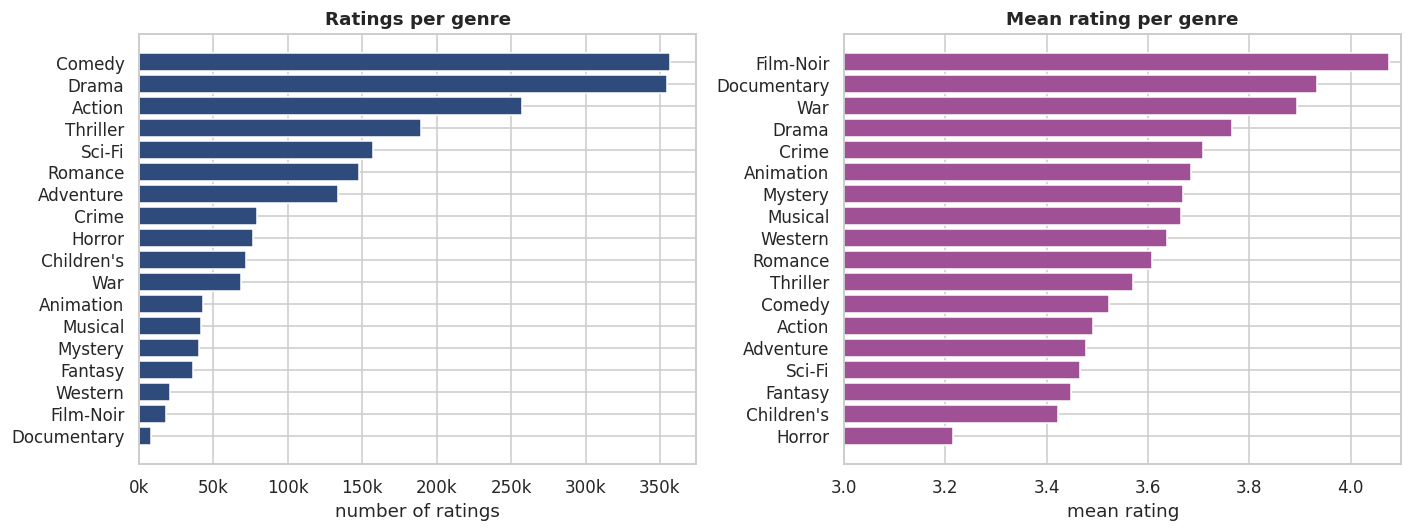

A film carries 1.65 genre labels on average.


,ratings,avg
Genre,,
Comedy,356580,3.522
Drama,354529,3.766
Action,257457,3.491
Thriller,189680,3.570
Sci-Fi,157294,3.467


In [14]:
# 7. Genre analysis
genre_rows = (movies.assign(Genre=movies.Genres.str.split("|")).explode("Genre")
              [["MovieID", "Genre"]])
genre_ratings = ratings.merge(genre_rows, on="MovieID")
genre_stats = (genre_ratings.groupby("Genre").Rating.agg(["size", "mean"])
               .rename(columns={"size": "ratings", "mean": "avg"})
               .sort_values("ratings", ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(genre_stats.index[::-1], genre_stats.ratings[::-1], color=PALETTE[0])
axes[0].set(title="Ratings per genre", xlabel="number of ratings")
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ordered = genre_stats.sort_values("avg")
axes[1].barh(ordered.index, ordered.avg, color=PALETTE[2])
axes[1].set(title="Mean rating per genre", xlabel="mean rating", xlim=(3.0, 4.1))
fig.tight_layout()
save_fig(fig, "07_genre_analysis.png"); plt.show()

labels_per_film = movies.Genres.str.split("|").str.len().mean()
print(f"A film carries {labels_per_film:.2f} genre labels on average.")
display(genre_stats.head(5).round(3))

**Insight.** Drama and Comedy dominate by volume, but volume and appreciation
come apart: Film-Noir, Documentary and War score highest on average while
Horror sits at the bottom. Note that the model below never sees any of this —
genres are used only to *audit* the embeddings in section 15.

saved -> outputs/eda/08_ratings_over_time.png


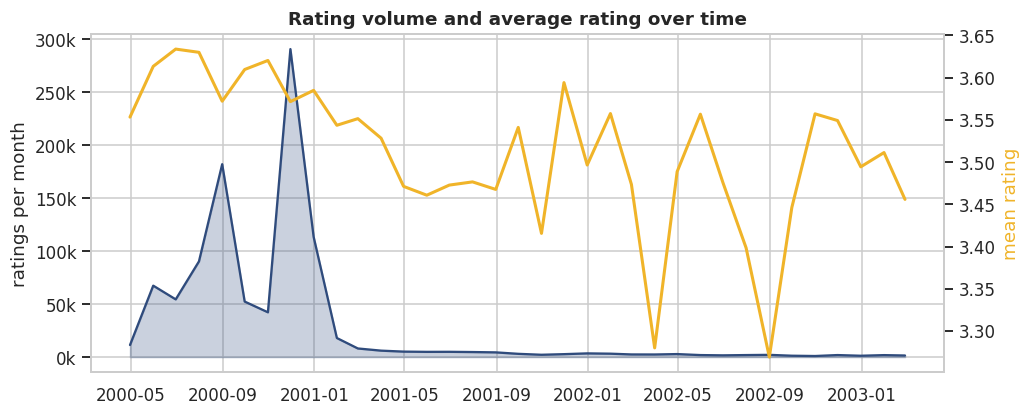

         count      mean       std      min      25%      50%       75%  \
ratings   35.0  28577.40  60147.39  1014.00  2009.50  3496.00  14700.00   
avg       35.0      3.51      0.09     3.27     3.47     3.53      3.56   

               max  
ratings  290793.00  
avg           3.63  


In [15]:
# 8. Rating behaviour over time
monthly = (ratings.set_index("Datetime").Rating
           .resample("ME").agg(["size", "mean"]).dropna())

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.fill_between(monthly.index, monthly["size"], color=PALETTE[0], alpha=0.25)
ax1.plot(monthly.index, monthly["size"], color=PALETTE[0], lw=1.5)
ax1.set(title="Rating volume and average rating over time", xlabel="", ylabel="ratings per month")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v/1000:.0f}k"))
ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["mean"], color=PALETTE[1], lw=2)
ax2.set_ylabel("mean rating", color=PALETTE[1])
ax2.grid(False)
save_fig(fig, "08_ratings_over_time.png"); plt.show()

print(monthly.rename(columns={"size": "ratings", "mean": "avg"}).describe().round(2).T)

**Insight.** Nearly half the dataset was contributed in the first few months
after MovieLens 1M opened, and the monthly mean drifts by roughly a quarter of a
star. That temporal cohort structure leaks into the embeddings: films released
and rated in the same window look similar to the model partly *because* they
were watched in the same period — a real limitation, revisited in section 15.

saved -> outputs/eda/09_sparsity.png


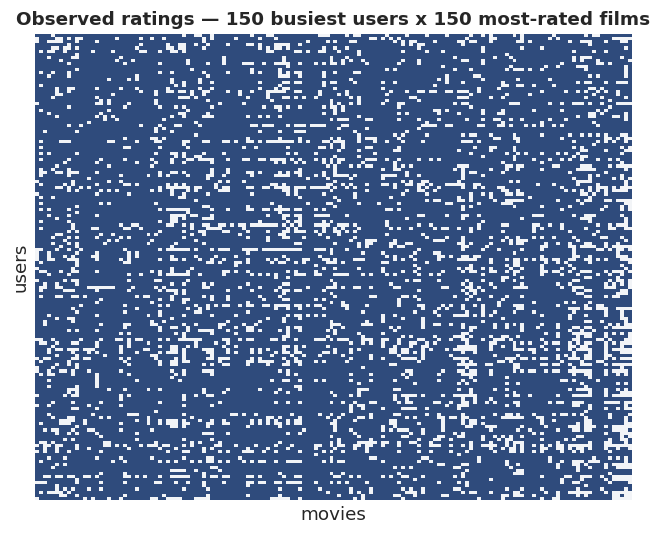

Full matrix       : 6,040 users x 3,706 movies = 22,384,240 cells
Observed ratings  : 1,000,209
Sparsity          : 95.5316% empty  (density 4.47%)
Densest corner above: 83.1% filled


In [16]:
# 9. Sparsity
n_users_total  = ratings.UserID.nunique()
n_movies_rated = ratings.MovieID.nunique()
possible = n_users_total * n_movies_rated
sparsity = 1 - len(ratings) / possible

sample_users  = ratings.UserID.value_counts().head(150).index
sample_movies = ratings.MovieID.value_counts().head(150).index
patch = (ratings[ratings.UserID.isin(sample_users) & ratings.MovieID.isin(sample_movies)]
         .pivot_table(index="UserID", columns="MovieID", values="Rating"))

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(patch.notna(), cbar=False, cmap=["#f2f4f7", PALETTE[0]], ax=ax)
ax.set(title="Observed ratings — 150 busiest users x 150 most-rated films",
       xlabel="movies", ylabel="users", xticks=[], yticks=[])
save_fig(fig, "09_sparsity.png"); plt.show()

print(f"Full matrix       : {n_users_total:,} users x {n_movies_rated:,} movies = {possible:,} cells")
print(f"Observed ratings  : {len(ratings):,}")
print(f"Sparsity          : {sparsity:.4%} empty  (density {1-sparsity:.2%})")
print(f"Densest corner above: {patch.notna().to_numpy().mean():.1%} filled")

**Insight.** 95.5% of the matrix is empty — and that is the *densest possible*
corner shown in the heatmap. Sparsity is the central problem of collaborative
filtering: the model has to infer 21 million unknown preferences from 1 million
observed ones, which is only possible because tastes are highly correlated.

## 06. The User–Movie Interaction Matrix

**Orientation matters, and it is a modelling decision, not a formatting one.**

A rating matrix can be fed to an autoencoder two ways:

| orientation | one training sample is… | the bottleneck yields |
|---|---|---|
| user-based (U-AutoRec) | a user's ratings over all movies | one vector per **user** |
| item-based (I-AutoRec) | a movie's ratings from all users | one vector per **movie** |

This project recommends *movies similar to a movie*, so it uses the **item-based**
orientation: rows are movies, columns are users. The bottleneck then produces
exactly what the recommender needs — one latent vector per film — with no
post-hoc reinterpretation. Section 10 comes back to why that distinction is worth
being pedantic about.

It also happens to be the better-conditioned problem here: 3,706 movies averaging
270 ratings each is a denser learning signal per sample than 6,040 users
averaging 166.

**Missing entries stay missing.** The matrix is stored as a SciPy CSR sparse
matrix, where an absent cell means *unobserved*, not *rated zero*.

In [17]:
movie_ids = np.sort(ratings.MovieID.unique())      # only films that were rated
user_ids  = np.sort(ratings.UserID.unique())
movie_to_index = {int(m): i for i, m in enumerate(movie_ids)}
user_to_index  = {int(u): i for i, u in enumerate(user_ids)}
index_to_movie = {i: int(m) for m, i in movie_to_index.items()}

N_MOVIES, N_USERS = len(movie_ids), len(user_ids)

row = ratings.MovieID.map(movie_to_index).to_numpy()
col = ratings.UserID.map(user_to_index).to_numpy()
full_matrix = csr_matrix((ratings.Rating.to_numpy(np.float32), (row, col)),
                         shape=(N_MOVIES, N_USERS))

dense_mb  = N_MOVIES * N_USERS * 4 / 1e6
sparse_mb = (full_matrix.data.nbytes + full_matrix.indices.nbytes + full_matrix.indptr.nbytes) / 1e6
print(f"Matrix shape       : {N_MOVIES:,} movies x {N_USERS:,} users")
print(f"Stored ratings     : {full_matrix.nnz:,}")
print(f"Density            : {full_matrix.nnz / (N_MOVIES * N_USERS):.2%}")
print(f"Dense float32 size : {dense_mb:,.1f} MB")
print(f"CSR sparse size    : {sparse_mb:,.1f} MB  ({dense_mb/sparse_mb:.1f}x smaller)")
assert full_matrix.nnz == len(ratings), "every rating must land in exactly one cell"
print("\nNo user or movie was filtered out: all "
      f"{N_USERS:,} users and all {N_MOVIES:,} rated films are in the matrix.")

Matrix shape       : 3,706 movies x 6,040 users
Stored ratings     : 1,000,209
Density            : 4.47%
Dense float32 size : 89.5 MB
CSR sparse size    : 8.0 MB  (11.2x smaller)

No user or movie was filtered out: all 6,040 users and all 3,706 rated films are in the matrix.


## 07. Train / Validation / Test Split

**The split is per rating, stratified by user (80 / 10 / 20 → 80 / 10 / 10).**
Each user's ratings are shuffled with a fixed seed and cut 80/10/10, so every
user contributes to all three sets. Alternatives and why they lost:

* *Random split over all ratings* — a light user can land entirely in test, so the
  model is asked about someone it has never seen.
* *Leave-one-out* — the standard for pure ranking papers, but one held-out item
  per user gives a very noisy RMSE.
* *Time-based split* — the most realistic for production, and the one to reach for
  if the goal were forecasting. It confounds this evaluation because the dataset's
  first months carry half the ratings, so a time cut also changes the popularity
  mix. Noted as a limitation rather than used silently.

**Leakage control.** The validation and test ratings are removed from the matrix
the network *reads*, and only the training cells contribute to the loss. Both
properties are asserted below rather than asserted in prose.

In [18]:
rng = np.random.default_rng(SEED)
shuffled = ratings.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
position = shuffled.groupby("UserID").cumcount()
group_size = shuffled.groupby("UserID")["UserID"].transform("size")
percentile = position / group_size

shuffled["split"] = np.where(percentile < TRAIN_FRAC, "train",
                     np.where(percentile < TRAIN_FRAC + VAL_FRAC, "val", "test"))

split_counts = shuffled.split.value_counts()[["train", "val", "test"]]
summary = pd.DataFrame({
    "ratings": split_counts,
    "share": (split_counts / len(shuffled)).map("{:.1%}".format),
    "users": [shuffled[shuffled.split == s].UserID.nunique() for s in split_counts.index],
    "movies": [shuffled[shuffled.split == s].MovieID.nunique() for s in split_counts.index],
})
display(summary)

train_df = shuffled[shuffled.split == "train"]
val_df   = shuffled[shuffled.split == "val"]
test_df  = shuffled[shuffled.split == "test"]

# --- leakage checks -------------------------------------------------------
key = lambda df: set(zip(df.UserID, df.MovieID))
train_keys, val_keys, test_keys = key(train_df), key(val_df), key(test_df)
assert not (train_keys & val_keys), "train/val overlap"
assert not (train_keys & test_keys), "train/test overlap"
assert not (val_keys & test_keys), "val/test overlap"
assert len(train_keys) + len(val_keys) + len(test_keys) == len(ratings), "ratings lost in the split"
print("No (user, movie) pair appears in more than one split.")
print(f"Every user appears in train: {train_df.UserID.nunique() == N_USERS}")
print(f"Users with at least one test rating: {test_df.UserID.nunique():,} / {N_USERS:,}")
print(f"Movies represented in train: {train_df.MovieID.nunique():,} / {N_MOVIES:,}")

,ratings,share,users,movies
split,,,,
train,802553,80.2%,6040,3677
val,100273,10.0%,6040,3325
test,97383,9.7%,6040,3304


No (user, movie) pair appears in more than one split.
Every user appears in train: True
Users with at least one test rating: 6,040 / 6,040
Movies represented in train: 3,677 / 3,706


## 08. Preprocessing — and how missing ratings are handled

Two decisions carry the whole model:

**1. Ratings are scaled to `r / 5`, not `(r - 1) / 4`.**
Observed ratings therefore live in `{0.2, 0.4, 0.6, 0.8, 1.0}` and the value `0.0`
is left free to mean *unobserved*. Had we used the more common `(r-1)/4`, a
one-star rating would map to `0.0` and become indistinguishable from an empty
cell. The network's output layer is a sigmoid, matching this range.

**2. The loss is masked.** The zeros the network reads are structural padding, not
targets. The loss sums squared error over observed cells only and divides by their
count:

$$\mathcal{L} = \frac{\sum_{(i,u)} m_{iu}\,(r_{iu}-\hat r_{iu})^2}{\sum_{(i,u)} m_{iu}},
\qquad m_{iu} = 1 \text{ if the rating is observed}$$

Without the mask the network would spend nearly all its capacity learning to
output 0.0 for the 95.5% of cells that are empty, and would predict that everyone
hates everything.

Validation works the same way: the network is fed the **training** vector and
scored against the **validation** cells, so `val_loss` measures generalisation to
ratings it has never seen, with no leakage.

In [19]:
def to_matrix(df):
    """(movies x users) sparse matrix of ratings scaled to (0, 1]; 0 = unobserved."""
    return csr_matrix(
        (df.Rating.to_numpy(np.float32) / 5.0,
         (df.MovieID.map(movie_to_index).to_numpy(), df.UserID.map(user_to_index).to_numpy())),
        shape=(N_MOVIES, N_USERS), dtype=np.float32,
    )

train_sparse, val_sparse, test_sparse = to_matrix(train_df), to_matrix(val_df), to_matrix(test_df)

X_train = np.asarray(train_sparse.todense(), dtype=np.float32)   # network input AND target
Y_val   = np.asarray(val_sparse.todense(), dtype=np.float32)     # validation targets only

print(f"X_train {X_train.shape}  {X_train.nbytes/1e6:.0f} MB   observed cells {train_sparse.nnz:,}")
print(f"Y_val   {Y_val.shape}  observed cells {val_sparse.nnz:,}")
print(f"test    observed cells {test_sparse.nnz:,}")

# The input the network sees must contain no validation or test rating.
val_coo, test_coo = val_sparse.tocoo(), test_sparse.tocoo()
assert np.all(X_train[val_coo.row, val_coo.col] == 0.0), "validation ratings leaked into the input"
assert np.all(X_train[test_coo.row, test_coo.col] == 0.0), "test ratings leaked into the input"
print("\nLeakage check passed: every validation and test cell is empty in the network input.")

observed = X_train[X_train > 0]
print(f"\nScaled observed values: {np.unique(observed)}  (= ratings 1-5 divided by 5)")
print(f"Share of the input matrix that is structurally empty: {(X_train == 0).mean():.2%}")

train_support = np.asarray(train_sparse.getnnz(axis=1)).ravel()   # ratings per movie in train
print(f"Movies with zero training ratings: {(train_support == 0).sum()}")

X_train (3706, 6040)  90 MB   observed cells 802,553
Y_val   (3706, 6040)  observed cells 100,273
test    observed cells 97,383

Leakage check passed: every validation and test cell is empty in the network input.

Scaled observed values: [0.2 0.4 0.6 0.8 1. ]  (= ratings 1-5 divided by 5)
Share of the input matrix that is structurally empty: 96.41%
Movies with zero training ratings: 29


## 09. Deep Autoencoder Architecture

```
input   6,040 user ratings for one movie   (0 = unobserved)
  |  Dense 512  ReLU        + L2, Dropout 0.2
  |  Dense 256  ReLU        + L2, Dropout 0.2
  |  Dense 128  linear      <-- the movie embedding
  |  Dense 256  ReLU        + L2, Dropout 0.2
  |  Dense 512  ReLU        + L2
output  6,040 reconstructed ratings        (sigmoid, x5 -> stars)
```

Design choices, each with a reason:

* **A linear bottleneck.** ReLU there would clamp every negative coordinate to
  zero and force all embeddings into the positive orthant, compressing the range
  of cosine similarity. Linear keeps the geometry.
* **Dropout on the hidden layers, not the input.** Dropping input ratings would
  add noise to an already 95%-empty vector.
* **Sigmoid output.** Ratings are bounded, so the reconstruction should be too.
* **L2 regularisation** (`1e-5`) — the standard AutoRec remedy for a decoder with
  6,040 outputs per film.
* **Adam** with early stopping on the *validation* masked RMSE, and a learning
  rate that halves on plateau.

`masked_rmse` reports error in stars (0–5), so it is directly comparable to the
RMSE numbers quoted in the recommender-systems literature.

In [20]:
# Keras 3 exposes this as keras.saving.*; TensorFlow's bundled shim only as
# keras.utils.*. Resolving it here keeps the notebook portable across both.
try:
    register_serializable = keras.saving.register_keras_serializable
except AttributeError:
    register_serializable = keras.utils.register_keras_serializable


@register_serializable(package="cinelatent")
def masked_mse(y_true, y_pred):
    """MSE over observed ratings only (y_true == 0 marks an unobserved cell)."""
    mask = tf.cast(y_true > 0.0, tf.float32)
    squared_error = tf.square((y_true - y_pred) * mask)
    return tf.reduce_sum(squared_error) / tf.maximum(tf.reduce_sum(mask), 1.0)


@register_serializable(package="cinelatent")
def masked_rmse(y_true, y_pred):
    """Same, reported on the original 1-5 star scale (x5 before squaring)."""
    mask = tf.cast(y_true > 0.0, tf.float32)
    squared_error = tf.square((y_true - y_pred) * mask * 5.0)
    return tf.sqrt(tf.reduce_sum(squared_error) / tf.maximum(tf.reduce_sum(mask), 1.0))


def build_autoencoder(n_inputs, latent_dim=LATENT_DIM, hidden=HIDDEN_DIMS,
                      dropout=DROPOUT, l2=L2_REG):
    reg = keras.regularizers.l2(l2)
    inputs = keras.Input(shape=(n_inputs,), name="ratings_in")

    x = inputs
    for i, units in enumerate(hidden, start=1):
        x = layers.Dense(units, activation="relu", kernel_regularizer=reg, name=f"encoder_{i}")(x)
        x = layers.Dropout(dropout, name=f"encoder_dropout_{i}")(x)

    latent = layers.Dense(latent_dim, activation=None, kernel_regularizer=reg, name="latent")(x)

    x = latent
    for i, units in enumerate(reversed(hidden), start=1):
        x = layers.Dense(units, activation="relu", kernel_regularizer=reg, name=f"decoder_{i}")(x)
        if i < len(hidden):
            x = layers.Dropout(dropout, name=f"decoder_dropout_{i}")(x)

    outputs = layers.Dense(n_inputs, activation="sigmoid", name="ratings_out")(x)
    return keras.Model(inputs, outputs, name="deep_item_autoencoder")


keras.utils.set_random_seed(SEED)
autoencoder = build_autoencoder(N_USERS)
autoencoder.compile(optimizer=keras.optimizers.Adam(LEARNING_RATE),
                    loss=masked_mse, metrics=[masked_rmse])
autoencoder.summary()

compression = N_USERS / LATENT_DIM
print(f"\nEach movie is compressed from {N_USERS:,} user ratings to {LATENT_DIM} numbers "
      f"({compression:.0f}x).")

Model: "deep_item_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ratings_in (InputLayer)         │ (None, 6040)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_1 (Dense)               │ (None, 512)            │     3,092,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_1 (Dropout)     │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_2 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_dropout_2 (Dropout)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_1 (Dense)               │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_dropout_1 (Dropout)     │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_2 (Dense)               │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ratings_out (Dense)             │ (None, 6040)           │     3,098,520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,344 (24.87 MB)

 Trainable params: 6,520,344 (24.87 MB)

 Non-trainable params: 0 (0.00 B)


Each movie is compressed from 6,040 user ratings to 128 numbers (47x).


## 10. What exactly *is* an embedding here? (the precision section)

This is the step people most often get wrong, so it is worth stating exactly what
each tensor means.

The network is trained on **movie vectors**: sample $i$ is film $i$ and its 6,040
coordinates are the ratings that every user gave that film. Consequently:

| tensor | shape | meaning |
|---|---|---|
| `latent` output, `encoder.predict(X)` | (3706, 128) | **movie embeddings** — one row *is* a film |
| `autoencoder.predict(X)` | (3706, 6040) | **reconstructed ratings**; cell (i, u) is the predicted rating of user *u* for film *i* |
| `Dense.weights` of `encoder_1` | (6040, 512) | user-side weights: how each user's opinion loads onto the first hidden layer |

So a *movie* embedding needs no derivation — it falls out of the bottleneck
because a movie is what a sample is. Two films are close in that space when the
same users rated them similarly, which is the definition of item-based
collaborative filtering.

**What a user embedding would be.** There is no per-user latent vector in this
model. Getting one would mean either (a) training the transposed
(user-based) autoencoder, whose bottleneck then holds users and whose *movie*
representations would have to be derived from decoder weights — the ambiguous
case this design avoids — or (b) treating a user as a bag of the films they liked,
which is what `recommend_from_profile` does in section 13 without inventing a new
latent space.

**The recommendation path stays inside one interpretation:**

```
movie -> row of the rating matrix -> encoder -> 128-d movie embedding
      -> cosine similarity against every other movie embedding -> Top-N
```

Reconstructed ratings are used only where they belong: predicting the *rating* a
user would give (RMSE/MAE in section 15).

## 11. Model Training

`FORCE_RETRAIN = False` means a model already saved in `models/` is reloaded
instead of retrained — the notebook can be re-run end to end in seconds once the
first training pass is done.

In [21]:
MODEL_PATH = MODELS_DIR / "autoencoder.keras"
HISTORY_PATH = MODELS_DIR / "training_history.json"

# Registration above covers this session; passing them explicitly also lets a
# fresh script reload the model without importing this notebook's definitions.
CUSTOM_OBJECTS = {"masked_mse": masked_mse, "masked_rmse": masked_rmse,
                  "cinelatent>masked_mse": masked_mse,
                  "cinelatent>masked_rmse": masked_rmse}

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_masked_rmse", mode="min",
                                  patience=EARLY_STOP_PATIENCE,
                                  restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor="val_masked_rmse", mode="min",
                                      factor=0.5, patience=4, min_lr=1e-5, verbose=1),
]

if MODEL_PATH.exists() and not FORCE_RETRAIN:
    print(f"Loading the saved model from {MODEL_PATH} (set FORCE_RETRAIN = True to retrain)")
    autoencoder = keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
    history = json.loads(HISTORY_PATH.read_text()) if HISTORY_PATH.exists() else {}
else:
    start = time.time()
    fit_result = autoencoder.fit(
        X_train, X_train,                      # input and target are the same matrix
        validation_data=(X_train, Y_val),      # ...but validation targets are held-out cells
        epochs=MAX_EPOCHS, batch_size=BATCH_SIZE,
        callbacks=callbacks, shuffle=True, verbose=2,
    )
    history = {k: [float(v) for v in vals] for k, vals in fit_result.history.items()}
    elapsed = time.time() - start
    print(f"\nTrained {len(history['loss'])} epochs in {elapsed/60:.1f} min "
          f"({elapsed/len(history['loss']):.1f}s per epoch)")
    HISTORY_PATH.write_text(json.dumps(history))

best_epoch = int(np.argmin(history["val_masked_rmse"])) + 1
print(f"Best epoch: {best_epoch} of {len(history['val_masked_rmse'])} "
      f"(early stopping restored these weights)")
print(f"Validation masked RMSE at best epoch: {min(history['val_masked_rmse']):.4f} stars")

Epoch 1/60


58/58 - 7s - 123ms/step - loss: 0.0604 - masked_rmse: 1.0498 - val_loss: 0.0486 - val_masked_rmse: 0.9588 - learning_rate: 0.0010


Epoch 2/60


58/58 - 4s - 66ms/step - loss: 0.0462 - masked_rmse: 0.9539 - val_loss: 0.0443 - val_masked_rmse: 0.9481 - learning_rate: 0.0010


Epoch 3/60


...

Epoch 30/60


58/58 - 4s - 64ms/step - loss: 0.0258 - masked_rmse: 0.7670 - val_loss: 0.0327 - val_masked_rmse: 0.8713 - learning_rate: 1.2500e-04


Epoch 30: early stopping


Restoring model weights from the end of the best epoch: 20.



Trained 30 epochs in 2.5 min (5.1s per epoch)
Best epoch: 20 of 30 (early stopping restored these weights)
Validation masked RMSE at best epoch: 0.8695 stars


## 12. Training Curves

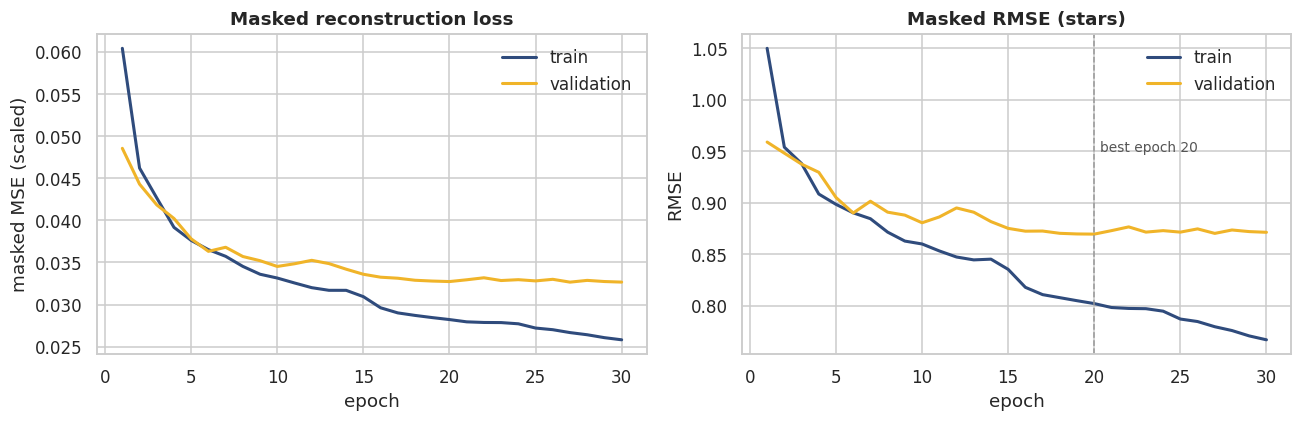

train RMSE 0.8021 | val RMSE 0.8695 | gap -0.0674
A small negative gap is expected: dropout is active during training, off during validation.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs_axis = range(1, len(history["loss"]) + 1)

axes[0].plot(epochs_axis, history["loss"], label="train", color=PALETTE[0], lw=2)
axes[0].plot(epochs_axis, history["val_loss"], label="validation", color=PALETTE[1], lw=2)
axes[0].set(title="Masked reconstruction loss", xlabel="epoch", ylabel="masked MSE (scaled)")

axes[1].plot(epochs_axis, history["masked_rmse"], label="train", color=PALETTE[0], lw=2)
axes[1].plot(epochs_axis, history["val_masked_rmse"], label="validation", color=PALETTE[1], lw=2)
axes[1].axvline(best_epoch, color="#999", ls="--", lw=1)
axes[1].annotate(f"best epoch {best_epoch}", xy=(best_epoch, max(history["val_masked_rmse"])),
                 xytext=(4, -6), textcoords="offset points", fontsize=9, color="#555")
axes[1].set(title="Masked RMSE (stars)", xlabel="epoch", ylabel="RMSE")

for ax in axes:
    ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "eda" / "10_training_curves.png")
plt.show()

gap = history["masked_rmse"][best_epoch - 1] - history["val_masked_rmse"][best_epoch - 1]
print(f"train RMSE {history['masked_rmse'][best_epoch-1]:.4f} | "
      f"val RMSE {history['val_masked_rmse'][best_epoch-1]:.4f} | gap {gap:+.4f}")
print("A small negative gap is expected: dropout is active during training, off during validation.")

## 13. Extract Latent Representations (movie embeddings)

The encoder is the input-to-bottleneck half of the trained network. Running the
full rating matrix through it yields one 128-dimensional vector per film.

In [23]:
encoder = keras.Model(autoencoder.input, autoencoder.get_layer("latent").output, name="encoder")
movie_embeddings = encoder.predict(X_train, batch_size=128, verbose=0).astype(np.float32)

norms = np.linalg.norm(movie_embeddings, axis=1)
print(f"movie_embeddings {movie_embeddings.shape}  ({movie_embeddings.nbytes/1e6:.1f} MB)")

# --- consistency checks ---------------------------------------------------
assert movie_embeddings.shape[0] == N_MOVIES == len(movie_ids), "one embedding per movie"
assert movie_embeddings.shape[1] == LATENT_DIM
assert len(movie_to_index) == N_MOVIES and len(index_to_movie) == N_MOVIES
assert all(movie_to_index[index_to_movie[i]] == i for i in range(N_MOVIES)), "mapping not invertible"
assert np.isfinite(movie_embeddings).all(), "non-finite values in the embeddings"

probe_index = movie_to_index[1]                      # MovieID 1 = Toy Story
probe_title = movies.set_index("MovieID").loc[1, "Title"]
single = encoder.predict(X_train[probe_index:probe_index + 1], verbose=0)[0]
assert np.allclose(single, movie_embeddings[probe_index], atol=1e-5)

print(f"Mapping is consistent: row {probe_index} <-> MovieID {index_to_movie[probe_index]} "
      f"({probe_title})")
print(f"Embeddings with zero norm: {(norms == 0).sum()}")
print(f"Norm: min {norms.min():.2f} | median {np.median(norms):.2f} | max {norms.max():.2f}")

movie_embeddings (3706, 128)  (1.9 MB)
Mapping is consistent: row 0 <-> MovieID 1 (Toy Story (1995))
Embeddings with zero norm: 0
Norm: min 1.13 | median 2.78 | max 32.80


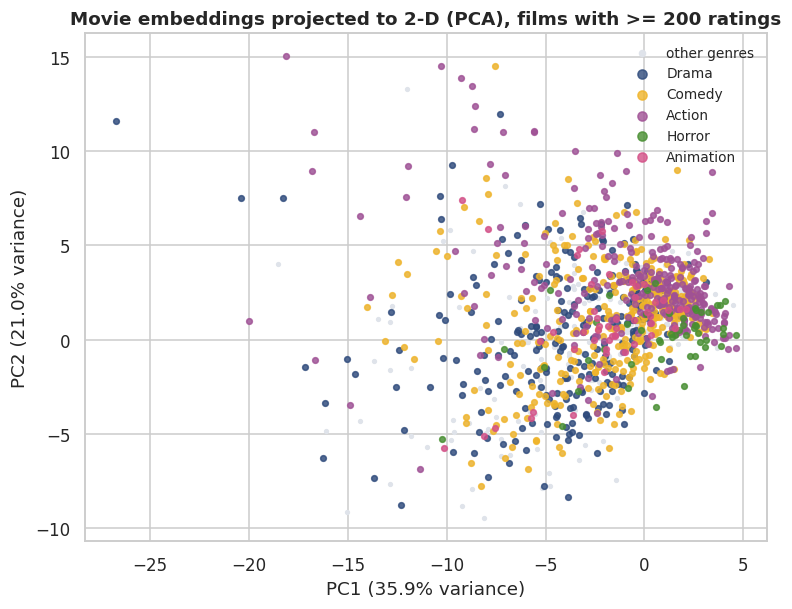

Genre labels were never shown to the model — any separation here is learned purely from co-rating patterns.


In [24]:
# Do the embeddings organise films in a way a human recognises? Project to 2-D.
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=SEED)
coords = pca.fit_transform(movie_embeddings)

primary_genre = (movies.set_index("MovieID").loc[movie_ids, "Genres"]
                 .str.split("|").str[0].to_numpy())
popular = train_support >= 200
highlight = ["Drama", "Comedy", "Action", "Horror", "Animation"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(coords[popular, 0], coords[popular, 1], s=6, c="#dfe3ea", label="other genres")
for genre, colour in zip(highlight, PALETTE):
    sel = popular & (primary_genre == genre)
    ax.scatter(coords[sel, 0], coords[sel, 1], s=14, color=colour, alpha=0.8, label=genre)
ax.set(title="Movie embeddings projected to 2-D (PCA), films with >= 200 ratings",
       xlabel=f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)",
       ylabel=f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.legend(frameon=False, markerscale=1.6, fontsize=9)
fig.savefig(OUTPUT_DIR / "eda" / "11_embedding_projection.png")
plt.show()

print("Genre labels were never shown to the model — any separation here is learned "
      "purely from co-rating patterns.")

## 14. Build the Recommendation Engine

The engine is written to `src/recommender.py` so that this notebook and the
Streamlit app run *exactly the same code*. The cell below is the file: running it
creates the module, and the cell after imports it.

Its contract:

1. accept a title → 2. resolve it to a MovieID → 3. fetch its embedding →
4. cosine-compare with every other embedding → 5. drop the film itself and
low-support films → 6. return the Top-N with titles and metadata.

Handled explicitly: unknown titles (with close-match suggestions), ambiguous
partial matches, films with no usable embedding, an empty candidate pool, and an
invalid `top_n`.

In [25]:
%%writefile src/recommender.py
"""
Recommendation engine built on the movie embeddings produced by the notebook.

The notebook trains an *item-based* deep autoencoder: every movie is one input
sample, described by the ratings it received from all 6,040 users. The
bottleneck layer therefore produces one latent vector **per movie**, and
cosine similarity in that latent space is a similarity between movies whose
only signal is "which users rated these two films the same way" -- i.e.
collaborative filtering, not content matching.

This module only *consumes* the saved artifacts (embeddings + id mapping); it
never trains anything, so it is safe to import from a Streamlit app.
"""

from __future__ import annotations

import difflib
import pickle
from pathlib import Path
from typing import Iterable, List, Optional, Sequence

import numpy as np
import pandas as pd

__all__ = [
    "MovieRecommender",
    "MovieNotFoundError",
    "AmbiguousTitleError",
    "RecommenderError",
]

DEFAULT_MODELS_DIR = Path(__file__).resolve().parents[1] / "models"


class RecommenderError(Exception):
    """Base class for recommender failures."""


class MovieNotFoundError(RecommenderError):
    """The requested title is not in the catalogue (or has no embedding)."""

    def __init__(self, message: str, suggestions: Optional[Sequence[str]] = None):
        super().__init__(message)
        self.suggestions = list(suggestions or [])


class AmbiguousTitleError(RecommenderError):
    """The query matched several titles and `on_ambiguous='raise'` was set."""

    def __init__(self, message: str, candidates: Optional[Sequence[str]] = None):
        super().__init__(message)
        self.candidates = list(candidates or [])


class MovieRecommender:
    """
    Parameters
    ----------
    embeddings : np.ndarray, shape (n_movies, latent_dim)
    catalog : pd.DataFrame
        One row per embedding, aligned by position, with columns
        MovieID, Title, Genres, RatingCount, MeanRating.
    default_min_support : int
        Movies with fewer than this many *training* ratings are excluded from
        the candidate pool by default: with only a handful of ratings a latent
        vector is dominated by noise. They remain in the catalogue and can be
        re-enabled with `min_support=0`.
    """

    def __init__(
        self,
        embeddings: np.ndarray,
        catalog: pd.DataFrame,
        default_min_support: int = 10,
    ) -> None:
        embeddings = np.asarray(embeddings, dtype=np.float32)
        if embeddings.ndim != 2:
            raise ValueError(f"embeddings must be 2-D, got shape {embeddings.shape}")
        if len(catalog) != embeddings.shape[0]:
            raise ValueError(
                f"catalog rows ({len(catalog)}) != embeddings rows "
                f"({embeddings.shape[0]}) -- artifacts are out of sync."
            )

        self.embeddings = embeddings
        self.catalog = catalog.reset_index(drop=True)
        self.default_min_support = int(default_min_support)

        # Pre-normalise once: cosine similarity is then a plain dot product.
        norms = np.linalg.norm(self.embeddings, axis=1, keepdims=True)
        self._zero_norm = (norms.squeeze(-1) == 0)
        self._unit = self.embeddings / np.maximum(norms, 1e-10)

        self._title_to_pos = {
            str(t).lower(): i for i, t in enumerate(self.catalog["Title"])
        }
        self._id_to_pos = {
            int(m): i for i, m in enumerate(self.catalog["MovieID"])
        }
        # Support = how many ratings the model actually trained on for a movie.
        # `RatingCount` (whole dataset) is kept for display.
        if "TrainRatingCount" in self.catalog:
            self._support = self.catalog["TrainRatingCount"].to_numpy()
        elif "RatingCount" in self.catalog:
            self._support = self.catalog["RatingCount"].to_numpy()
        else:  # pragma: no cover - artifacts always carry rating counts
            self._support = np.full(len(self.catalog), np.inf)

        self._threshold_cache: dict[int, np.ndarray] = {}

    # ------------------------------------------------------------------ #
    # Neighbourhood truncation                                           #
    # ------------------------------------------------------------------ #
    def neighbourhood_threshold(self, k: int, chunk: int = 512) -> np.ndarray:
        """
        For every movie, the similarity of its k-th nearest neighbour.

        Item-based CF ranks much better when each item only votes for its k
        closest neighbours instead of the whole catalogue (measured in the
        notebook: P@10 0.059 -> 0.091). Computed in chunks so peak memory
        stays a few MB rather than an n x n matrix, and cached per k.
        """
        k = int(k)
        if k < 1:
            raise ValueError("k must be >= 1")
        if k in self._threshold_cache:
            return self._threshold_cache[k]

        n = self._unit.shape[0]
        k_eff = min(k, n - 1)
        thresholds = np.empty(n, dtype=np.float32)
        for start in range(0, n, chunk):
            block = self._unit[start : start + chunk] @ self._unit.T
            np.fill_diagonal(block[:, start : start + block.shape[0]], -np.inf)
            part = np.partition(block, -k_eff, axis=1)
            thresholds[start : start + block.shape[0]] = part[:, -k_eff]
        self._threshold_cache[k] = thresholds
        return thresholds

    # ------------------------------------------------------------------ #
    # Loading                                                            #
    # ------------------------------------------------------------------ #
    @classmethod
    def load(cls, models_dir: "str | Path" = DEFAULT_MODELS_DIR, **kwargs) -> "MovieRecommender":
        """Load embeddings + mapping saved by the notebook."""
        models_dir = Path(models_dir)
        emb_path = models_dir / "movie_embeddings.npy"
        map_path = models_dir / "movie_id_mapping.pkl"
        for path in (emb_path, map_path):
            if not path.exists():
                raise FileNotFoundError(
                    f"Missing artifact: {path}. Run the notebook "
                    "(section 19, 'Save Model Artifacts') first."
                )
        embeddings = np.load(emb_path)
        with open(map_path, "rb") as fh:
            mapping = pickle.load(fh)
        catalog = mapping["catalog"] if isinstance(mapping, dict) else mapping
        if not isinstance(catalog, pd.DataFrame):
            catalog = pd.DataFrame(catalog)
        return cls(embeddings, catalog, **kwargs)

    # ------------------------------------------------------------------ #
    # Title resolution                                                   #
    # ------------------------------------------------------------------ #
    @property
    def titles(self) -> List[str]:
        return self.catalog["Title"].tolist()

    def search_titles(self, query: str, limit: int = 20) -> List[str]:
        """Substring search over the catalogue, most-rated titles first."""
        if not query or not str(query).strip():
            return []
        q = str(query).strip().lower()
        mask = self.catalog["Title"].str.lower().str.contains(q, regex=False)
        hits = self.catalog[mask].sort_values("RatingCount", ascending=False)
        return hits["Title"].head(limit).tolist()

    def resolve_title(self, movie_title: str, on_ambiguous: str = "best") -> int:
        """
        Map a user-supplied title to a catalogue row index.

        Resolution order: exact (case-insensitive) -> prefix -> substring.
        Ties are broken by popularity when `on_ambiguous='best'`; with
        `on_ambiguous='raise'` an AmbiguousTitleError lists the candidates.
        """
        if movie_title is None or not str(movie_title).strip():
            raise MovieNotFoundError("Please provide a movie title.")
        query = str(movie_title).strip()
        lowered = query.lower()

        if lowered in self._title_to_pos:
            return self._title_to_pos[lowered]

        titles_lower = self.catalog["Title"].str.lower()
        prefix = np.flatnonzero(titles_lower.str.startswith(lowered).to_numpy())
        matches = prefix if len(prefix) else np.flatnonzero(
            titles_lower.str.contains(lowered, regex=False).to_numpy()
        )

        if len(matches) == 0:
            suggestions = difflib.get_close_matches(query, self.titles, n=5, cutoff=0.6)
            raise MovieNotFoundError(
                f"'{query}' is not in the MovieLens catalogue."
                + (f" Did you mean: {', '.join(suggestions)}?" if suggestions else ""),
                suggestions=suggestions,
            )
        if len(matches) == 1:
            return int(matches[0])

        ranked = matches[np.argsort(-self._support[matches])]
        candidates = [self.catalog["Title"].iloc[i] for i in ranked[:10]]
        if on_ambiguous == "raise":
            raise AmbiguousTitleError(
                f"'{query}' matches {len(matches)} titles: {', '.join(candidates[:5])}...",
                candidates=candidates,
            )
        return int(ranked[0])

    # ------------------------------------------------------------------ #
    # Recommendations                                                    #
    # ------------------------------------------------------------------ #
    def recommend_movies(
        self,
        movie_title: str,
        top_n: int = 10,
        min_support: Optional[int] = None,
        on_ambiguous: str = "best",
        same_genre_only: bool = False,
    ) -> pd.DataFrame:
        """
        Return the `top_n` movies most similar to `movie_title`.

        Similarity is the cosine of the angle between the two movies' latent
        vectors (range -1..1; in practice 0..1 for this model).
        """
        if not isinstance(top_n, (int, np.integer)) or isinstance(top_n, bool):
            raise ValueError(f"top_n must be an integer, got {type(top_n).__name__}.")
        top_n = int(top_n)
        if top_n < 1:
            raise ValueError(f"top_n must be >= 1, got {top_n}.")

        min_support = self.default_min_support if min_support is None else int(min_support)
        pos = self.resolve_title(movie_title, on_ambiguous=on_ambiguous)
        query_row = self.catalog.iloc[pos]

        if self._zero_norm[pos]:
            raise MovieNotFoundError(
                f"'{query_row['Title']}' has an all-zero embedding "
                "(no usable training ratings), so similarity is undefined."
            )

        sims = self._unit @ self._unit[pos]

        eligible = (self._support >= min_support) & (~self._zero_norm)
        eligible[pos] = False  # never recommend the query movie back
        if same_genre_only:
            query_genres = set(str(query_row.get("Genres", "")).split("|"))
            eligible &= self.catalog["Genres"].apply(
                lambda g: bool(query_genres & set(str(g).split("|")))
            ).to_numpy()

        n_eligible = int(eligible.sum())
        if n_eligible == 0:
            raise RecommenderError(
                f"No candidate movies left after filtering (min_support={min_support}). "
                "Lower min_support and try again."
            )
        k = min(top_n, n_eligible)

        masked = np.where(eligible, sims, -np.inf)
        top_idx = np.argpartition(-masked, k - 1)[:k]
        top_idx = top_idx[np.argsort(-masked[top_idx])]

        out = self.catalog.iloc[top_idx][
            ["MovieID", "Title", "Genres", "RatingCount", "MeanRating"]
        ].copy()
        out.insert(0, "Rank", np.arange(1, len(out) + 1))
        out.insert(3, "Similarity", np.round(sims[top_idx], 4))
        out = out.reset_index(drop=True)
        out.attrs["query_title"] = query_row["Title"]
        out.attrs["query_movie_id"] = int(query_row["MovieID"])
        out.attrs["resolved_from"] = str(movie_title)
        out.attrs["min_support"] = min_support
        out.attrs["n_candidates"] = n_eligible
        if k < top_n:
            out.attrs["warning"] = f"Only {k} candidates available (requested {top_n})."
        if query_row.get("RatingCount", np.inf) < 20:
            out.attrs["low_support_query"] = (
                f"'{query_row['Title']}' has only {int(query_row['RatingCount'])} "
                "training ratings; its embedding is noisy."
            )
        return out

    def recommend_from_profile(
        self,
        liked_titles: Iterable[str],
        top_n: int = 10,
        min_support: Optional[int] = None,
        neighbourhood_k: Optional[int] = 50,
    ) -> pd.DataFrame:
        """
        Score every movie against a small set of liked movies.

        This is the same scorer that the notebook evaluates against a
        popularity baseline: a candidate only collects similarity from a liked
        movie that sits inside the candidate's `neighbourhood_k` nearest
        neighbours. Pass `neighbourhood_k=None` for a plain mean similarity.
        """
        liked_titles = [t for t in liked_titles if str(t).strip()]
        if not liked_titles:
            raise MovieNotFoundError("Provide at least one movie you liked.")
        top_n = int(top_n)
        if top_n < 1:
            raise ValueError("top_n must be >= 1.")
        min_support = self.default_min_support if min_support is None else int(min_support)

        positions = [self.resolve_title(t) for t in liked_titles]
        sim_block = self._unit @ self._unit[positions].T  # (n_movies, n_liked)
        if neighbourhood_k:
            thresholds = self.neighbourhood_threshold(neighbourhood_k)
            sim_block = np.where(sim_block >= thresholds[:, None], sim_block, 0.0)
            sims = sim_block.sum(axis=1)
        else:
            sims = sim_block.mean(axis=1)

        eligible = (self._support >= min_support) & (~self._zero_norm)
        eligible[positions] = False
        k = min(top_n, int(eligible.sum()))
        if k == 0:
            raise RecommenderError("No candidate movies left after filtering.")

        masked = np.where(eligible, sims, -np.inf)
        top_idx = np.argpartition(-masked, k - 1)[:k]
        top_idx = top_idx[np.argsort(-masked[top_idx])]

        out = self.catalog.iloc[top_idx][
            ["MovieID", "Title", "Genres", "RatingCount", "MeanRating"]
        ].copy()
        out.insert(0, "Rank", np.arange(1, len(out) + 1))
        out.insert(3, "Similarity", np.round(sims[top_idx], 4))
        out = out.reset_index(drop=True)
        out.attrs["profile"] = [self.catalog["Title"].iloc[p] for p in positions]
        return out

Overwriting src/recommender.py


In [26]:
import importlib
import src.recommender as recommender_module

importlib.reload(recommender_module)
from src.recommender import (AmbiguousTitleError, MovieNotFoundError,
                             MovieRecommender, RecommenderError)

# The catalogue: one row per embedding, in embedding order.
overall = ratings.groupby("MovieID").Rating.agg(["size", "mean"])
catalog = (movies.set_index("MovieID").loc[movie_ids, ["Title", "Genres"]]
           .assign(RatingCount=overall.loc[movie_ids, "size"].to_numpy(),
                   MeanRating=overall.loc[movie_ids, "mean"].to_numpy().round(3),
                   TrainRatingCount=train_support)
           .reset_index())

assert len(catalog) == len(movie_embeddings)
assert (catalog.MovieID.to_numpy() == movie_ids).all(), "catalogue order must match embedding order"

recommender = MovieRecommender(movie_embeddings, catalog, default_min_support=MIN_SUPPORT)


def recommend_movies(movie_title, top_n=10, **kwargs):
    """Top-N films whose latent vectors are closest to `movie_title`."""
    return recommender.recommend_movies(movie_title, top_n=top_n, **kwargs)


print(recommender.__class__.__name__, "ready:",
      f"{len(catalog):,} films, {movie_embeddings.shape[1]}-d embeddings")
display(catalog.head(3))

MovieRecommender ready: 3,706 films, 128-d embeddings


,MovieID,Title,Genres,RatingCount,MeanRating,TrainRatingCount
0,1,Toy Story (1995),Animation|Children's|Comedy,2077,4.147,1694
1,2,Jumanji (1995),Adventure|Children's|Fantasy,701,3.201,562
2,3,Grumpier Old Men (1995),Comedy|Romance,478,3.017,385


## 15. Test the Recommendations

Four films from different corners of the catalogue, then the error paths.

In [27]:
for title in ["Toy Story (1995)", "Star Wars: Episode IV - A New Hope (1977)",
              "Godfather, The (1972)", "Alien (1979)"]:
    result = recommend_movies(title, top_n=8)
    print(f"\nBecause you watched  {result.attrs['query_title']}")
    print("-" * 78)
    for _, r in result.iterrows():
        print(f"  {r.Rank:>2}. {r.Title[:44]:<46} cos {r.Similarity:.3f}  "
              f"{r.Genres[:28]:<28} n={int(r.RatingCount):>4}")


Because you watched  Toy Story (1995)
------------------------------------------------------------------------------
   1. Toy Story 2 (1999)                             cos 0.981  Animation|Children's|Comedy  n=1585
   2. Aladdin (1992)                                 cos 0.958  Animation|Children's|Comedy| n=1351
   3. Bug's Life, A (1998)                           cos 0.944  Animation|Children's|Comedy  n=1703
   4. Lion King, The (1994)                          cos 0.907  Animation|Children's|Musical n=1121
   5. Who Framed Roger Rabbit? (1988)                cos 0.891  Adventure|Animation|Film-Noi n=1799
   6. Beauty and the Beast (1991)                    cos 0.887  Animation|Children's|Musical n=1060
   7. Shakespeare in Love (1998)                     cos 0.874  Comedy|Romance               n=2369
   8. Little Mermaid, The (1989)                     cos 0.869  Animation|Children's|Comedy| n=1035

Because you watched  Star Wars: Episode IV - A New Hope (1977)
------------------

In [28]:
# Error handling, exercised rather than described.
print("1. Unknown title")
try:
    recommend_movies("Attack of the Killer Notebook (2024)")
except MovieNotFoundError as exc:
    print(f"   MovieNotFoundError -> {exc}")

print("\n2. Misspelled title (close matches are suggested)")
try:
    recommend_movies("Godfathar, The (1972)")
except MovieNotFoundError as exc:
    print(f"   suggestions: {exc.suggestions}")

print("\n3. Ambiguous partial title, strict mode")
try:
    recommend_movies("Toy Story", on_ambiguous="raise")
except AmbiguousTitleError as exc:
    print(f"   candidates: {exc.candidates}")

print("\n4. Ambiguous partial title, default mode (most-rated match wins)")
print(f"   'Toy Story' -> {recommend_movies('Toy Story', top_n=1).attrs['query_title']}")

print("\n5. Invalid top_n")
for bad in (0, -5, 2.5):
    try:
        recommend_movies("Alien (1979)", top_n=bad)
    except ValueError as exc:
        print(f"   top_n={bad!r} -> ValueError: {exc}")

print("\n6. top_n larger than the candidate pool")
huge = recommend_movies("Alien (1979)", top_n=10_000)
print(f"   asked for 10,000, returned {len(huge)} -> {huge.attrs.get('warning')}")

print("\n7. A film almost nobody rated")
rare_title = catalog.nsmallest(1, "TrainRatingCount").iloc[0].Title
rare = recommend_movies(rare_title, top_n=3, min_support=0)
print(f"   {rare_title!r} -> {rare.attrs.get('low_support_query')}")

print("\n8. Impossible support filter (empty candidate pool)")
try:
    recommend_movies("Alien (1979)", min_support=10 ** 6)
except RecommenderError as exc:
    print(f"   RecommenderError -> {exc}")

1. Unknown title
   MovieNotFoundError -> 'Attack of the Killer Notebook (2024)' is not in the MovieLens catalogue. Did you mean: Attack of the Killer Tomatoes! (1980)?

2. Misspelled title (close matches are suggested)
   suggestions: ['Godfather, The (1972)', 'Godfather: Part II, The (1974)', 'Gate, The (1987)', 'MatchMaker, The (1997)', 'Good Earth, The (1937)']

3. Ambiguous partial title, strict mode
   candidates: ['Toy Story (1995)', 'Toy Story 2 (1999)']

4. Ambiguous partial title, default mode (most-rated match wins)
   'Toy Story' -> Toy Story (1995)

5. Invalid top_n
   top_n=0 -> ValueError: top_n must be >= 1, got 0.
   top_n=-5 -> ValueError: top_n must be >= 1, got -5.
   top_n=2.5 -> ValueError: top_n must be an integer, got float.

6. top_n larger than the candidate pool
   asked for 10,000, returned 3195 -> Only 3195 candidates available (requested 10000).

7. A film almost nobody rated
   'Target (1995)' -> 'Target (1995)' has only 1 training ratings; its embedding 

In [29]:
# Save a few example outputs for the README / portfolio.
REC_DIR = OUTPUT_DIR / "recommendations"
examples = {}
for title in ["Toy Story (1995)", "Matrix, The (1999)", "Fargo (1996)",
              "Silence of the Lambs, The (1991)"]:
    frame = recommend_movies(title, top_n=TOP_K)
    slug = "".join(ch if ch.isalnum() else "_" for ch in title.split(" (")[0]).lower()
    frame.to_csv(REC_DIR / f"{slug}.csv", index=False)
    examples[title] = frame
    print(f"saved -> {REC_DIR / (slug + '.csv')}")

display(examples["Matrix, The (1999)"])

saved -> outputs/recommendations/toy_story.csv
saved -> outputs/recommendations/matrix__the.csv
saved -> outputs/recommendations/fargo.csv
saved -> outputs/recommendations/silence_of_the_lambs__the.csv


,Rank,MovieID,Title,Similarity,Genres,RatingCount,MeanRating
0,1,1127,"Abyss, The (1989)",0.9254,Action|Adventure|Sci-Fi|Thriller,1715,3.684
1,2,3793,X-Men (2000),0.9150,Action|Sci-Fi,1511,3.821
2,3,589,Terminator 2: Judgment Day (1991),0.9012,Action|Sci-Fi|Thriller,2649,4.059
3,4,1196,Star Wars: Episode V - The Empire Strikes Back...,0.8936,Action|Adventure|Drama|Sci-Fi|War,2990,4.293
4,5,3578,Gladiator (2000),0.8811,Action|Drama,1924,4.106
5,6,1580,Men in Black (1997),0.8805,Action|Adventure|Comedy|Sci-Fi,2538,3.740
6,7,2916,Total Recall (1990),0.8743,Action|Adventure|Sci-Fi|Thriller,1996,3.682
7,8,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.8644,Action|Adventure|Romance|Sci-Fi|War,2883,4.023
8,9,1527,"Fifth Element, The (1997)",0.8603,Action|Sci-Fi,1377,3.641
9,10,592,Batman (1989),0.8528,Action|Adventure|Crime|Drama,1431,3.601


## 16. Recommendation Evaluation

Two different questions need two different measurements, and conflating them is
the most common way recommender results get oversold.

**(a) How accurate are the predicted ratings?** RMSE and MAE on the held-out test
cells, in stars. Compared against four baselines — a model that cannot beat
"predict this movie's average" has learned nothing.

**(b) How good is the Top-10 list?** Precision@10, Recall@10, Hit-Rate@10 and
NDCG@10, where a test rating of 4+ counts as relevant. The baseline here is
**popularity**, which is deceptively strong on MovieLens and is where many
published recommender comparisons quietly fail.

No plain "accuracy" is reported: predicting a five-star rating exactly right has
no meaningful notion of a correct/incorrect binary outcome.

In [30]:
# ---- (a) rating prediction --------------------------------------------------
predicted = np.clip(autoencoder.predict(X_train, batch_size=128, verbose=0) * 5.0, 1.0, 5.0)

test_coo = test_sparse.tocoo()
truth = test_coo.data * 5.0

def score(pred_values):
    err = truth - pred_values
    return float(np.sqrt(np.mean(err ** 2))), float(np.mean(np.abs(err)))

train_coo = train_sparse.tocoo()
train_stars = train_coo.data * 5.0
global_mean = float(train_stars.mean())

item_sum = np.zeros(N_MOVIES); item_cnt = np.zeros(N_MOVIES)
np.add.at(item_sum, train_coo.row, train_stars); np.add.at(item_cnt, train_coo.row, 1)
user_sum = np.zeros(N_USERS); user_cnt = np.zeros(N_USERS)
np.add.at(user_sum, train_coo.col, train_stars); np.add.at(user_cnt, train_coo.col, 1)
item_mean = np.where(item_cnt > 0, item_sum / np.maximum(item_cnt, 1), global_mean)
user_mean = np.where(user_cnt > 0, user_sum / np.maximum(user_cnt, 1), global_mean)

rating_rows = []
for name, values in [
    ("Global mean", np.full(len(truth), global_mean)),
    ("Movie mean", item_mean[test_coo.row]),
    ("User mean", user_mean[test_coo.col]),
    ("Movie + user bias", np.clip(global_mean + (item_mean - global_mean)[test_coo.row]
                                  + (user_mean - global_mean)[test_coo.col], 1, 5)),
    ("Deep autoencoder", predicted[test_coo.row, test_coo.col]),
]:
    rmse, mae = score(values)
    rating_rows.append({"model": name, "RMSE": round(rmse, 4), "MAE": round(mae, 4)})

rating_results = pd.DataFrame(rating_rows).sort_values("RMSE").reset_index(drop=True)
rating_results.to_csv(OUTPUT_DIR / "evaluation" / "rating_prediction_metrics.csv", index=False)
display(rating_results)

ae_rmse = rating_results.loc[rating_results.model == "Deep autoencoder", "RMSE"].iloc[0]
best_base = rating_results[rating_results.model != "Deep autoencoder"].RMSE.min()
print(f"Test ratings evaluated: {len(truth):,}")
print(f"Autoencoder RMSE {ae_rmse:.4f} vs best baseline {best_base:.4f} "
      f"({(best_base - ae_rmse)/best_base:.1%} lower error).")

,model,RMSE,MAE
0,Deep autoencoder,0.8604,0.6720
1,Movie + user bias,0.9321,0.7314
2,Movie mean,0.9800,0.7830
3,User mean,1.0334,0.8268
4,Global mean,1.1168,0.9332


Test ratings evaluated: 97,383
Autoencoder RMSE 0.8604 vs best baseline 0.9321 (7.7% lower error).


In [31]:
# ---- (b) top-N ranking ------------------------------------------------------
train_user = train_sparse.T.tocsr()          # users x movies
test_user  = test_sparse.T.tocsr()
seen_rows, seen_cols = train_user.nonzero()

test_indptr, test_indices, test_data = test_user.indptr, test_user.indices, test_user.data
relevant_sets = []
for u in range(N_USERS):
    span = slice(test_indptr[u], test_indptr[u + 1])
    relevant_sets.append(set(test_indices[span][test_data[span] * 5.0 >= RELEVANCE_THRESHOLD]))
evaluable = sum(1 for s in relevant_sets if s)


def evaluate_ranking(scores, name, min_support=0):
    """scores: (n_users, n_movies). Mutated in place to keep memory flat."""
    scores[seen_rows, seen_cols] = -np.inf          # never recommend a training item
    if min_support > 0:
        scores[:, train_support < min_support] = -np.inf
    top_idx = np.argpartition(-scores, TOP_K, axis=1)[:, :TOP_K]

    precision, recall, hits, ndcg = [], [], [], []
    for u in range(N_USERS):
        relevant = relevant_sets[u]
        if not relevant:
            continue
        ranked = top_idx[u][np.argsort(-scores[u, top_idx[u]])]
        flags = [1 if i in relevant else 0 for i in ranked]
        hit_count = sum(flags)
        precision.append(hit_count / TOP_K)
        recall.append(hit_count / len(relevant))
        hits.append(1 if hit_count else 0)
        dcg = sum(f / np.log2(rank + 2) for rank, f in enumerate(flags))
        idcg = sum(1 / np.log2(rank + 2) for rank in range(min(TOP_K, len(relevant))))
        ndcg.append(dcg / idcg if idcg else 0.0)

    return {"scorer": name, f"Precision@{TOP_K}": round(float(np.mean(precision)), 4),
            f"Recall@{TOP_K}": round(float(np.mean(recall)), 4),
            f"HitRate@{TOP_K}": round(float(np.mean(hits)), 4),
            f"NDCG@{TOP_K}": round(float(np.mean(ndcg)), 4)}


ranking_rows = []

popularity_scores = np.tile((item_cnt / item_cnt.max()).astype(np.float32), (N_USERS, 1))
ranking_rows.append(evaluate_ranking(popularity_scores, "Popularity baseline"))
del popularity_scores

ranking_rows.append(evaluate_ranking(np.ascontiguousarray(predicted.T), "Autoencoder reconstruction"))

unit = movie_embeddings / np.maximum(np.linalg.norm(movie_embeddings, axis=1, keepdims=True), 1e-10)
similarity = (unit @ unit.T).astype(np.float32)
np.fill_diagonal(similarity, 0.0)

liked = train_user.copy()
liked.data = (liked.data * 5.0 >= RELEVANCE_THRESHOLD).astype(np.float32)
liked.eliminate_zeros()

ranking_rows.append(evaluate_ranking(np.asarray(liked @ similarity, dtype=np.float32),
                                     "Embedding item-item (all neighbours)"))

# Neighbourhood truncation: a film only votes for its NEIGHBOURHOOD_K closest peers.
truncated = np.zeros_like(similarity)
nn_idx = np.argpartition(-similarity, NEIGHBOURHOOD_K, axis=1)[:, :NEIGHBOURHOOD_K]
rows = np.repeat(np.arange(N_MOVIES), NEIGHBOURHOOD_K)
truncated[rows, nn_idx.ravel()] = similarity[rows, nn_idx.ravel()]
ranking_rows.append(evaluate_ranking(np.asarray(liked @ truncated.T, dtype=np.float32),
                                     f"Embedding item-item (top-{NEIGHBOURHOOD_K} neighbours)"))
del truncated

ranking_results = pd.DataFrame(ranking_rows)
ranking_results.to_csv(OUTPUT_DIR / "evaluation" / "ranking_metrics.csv", index=False)
print(f"Users with at least one relevant test item: {evaluable:,} of {N_USERS:,}\n")
display(ranking_results)

Users with at least one relevant test item: 5,862 of 6,040



,scorer,Precision@10,Recall@10,HitRate@10,NDCG@10
0,Popularity baseline,0.0733,0.0861,0.4369,0.0986
1,Autoencoder reconstruction,0.0596,0.0669,0.3623,0.0813
2,Embedding item-item (all neighbours),0.0528,0.0728,0.3748,0.0735
3,Embedding item-item (top-50 neighbours),0.0927,0.1137,0.5179,0.1271


**How to read this table.**

* **Precision@10** — of the 10 films offered, how many the user actually rated 4+
  in the test period. Ceilings are low by construction: a user has only a handful
  of test ratings, so most of the 10 slots *cannot* be hits even for a perfect model.
* **Recall@10** — the share of the user's relevant test films that made the list.
* **Hit-Rate@10** — the share of users for whom at least one of the ten landed.
  The most intuitive number: "did this list contain anything they liked?"
* **NDCG@10** — as above but rewarding hits nearer the top.

Two results worth dwelling on. First, the autoencoder's *reconstruction* ranks
worse than plain popularity even though it wins clearly on RMSE — a model tuned
to predict the rating of films a user already chose to watch is not automatically
good at choosing *which* film to surface. Second, restricting each film to vote
only for its closest neighbours is what turns the embedding scorer into the
strongest ranker: without truncation, thousands of weak similarities drown the
signal.

In [32]:
# The recommender module and the vectorised evaluation must agree.
sample_user = int(np.argmax(np.asarray(liked.sum(axis=1)).ravel()))
liked_positions = liked[sample_user].indices[:12]
liked_titles = catalog.Title.iloc[liked_positions].tolist()

module_scores = recommender.recommend_from_profile(
    liked_titles, top_n=5, min_support=0, neighbourhood_k=NEIGHBOURHOOD_K)

thresholds = recommender.neighbourhood_threshold(NEIGHBOURHOOD_K)
block = similarity[:, liked_positions] + 0.0
manual = np.where(block >= thresholds[:, None], block, 0.0).sum(axis=1)
manual[liked_positions] = -np.inf
manual_top = catalog.Title.iloc[np.argsort(-manual)[:5]].tolist()

print(f"Profile of user #{sample_user} — first liked films: {liked_titles[:3]}\n")
print("module  :", module_scores.Title.tolist())
print("manual  :", manual_top)
assert set(module_scores.Title) == set(manual_top), "module and evaluation disagree"
assert module_scores.Title.iloc[0] == manual_top[0], "top recommendation differs"
print("\nThe module's scorer reproduces the evaluated algorithm exactly.")

Profile of user #4276 — first liked films: ['Toy Story (1995)', 'Heat (1995)', 'Tom and Huck (1995)']

module  : ['Usual Suspects, The (1995)', 'Perfect World, A (1993)', 'Simple Plan, A (1998)', 'Shakespeare in Love (1998)', 'Pleasantville (1998)']
manual  : ['Usual Suspects, The (1995)', 'Perfect World, A (1993)', 'Simple Plan, A (1998)', 'Shakespeare in Love (1998)', 'Pleasantville (1998)']

The module's scorer reproduces the evaluated algorithm exactly.


Mean genre Jaccard overlap with the top-10 nearest films: 0.4179
Same statistic for 10 random films:                        0.1749
Ratio: 2.4x


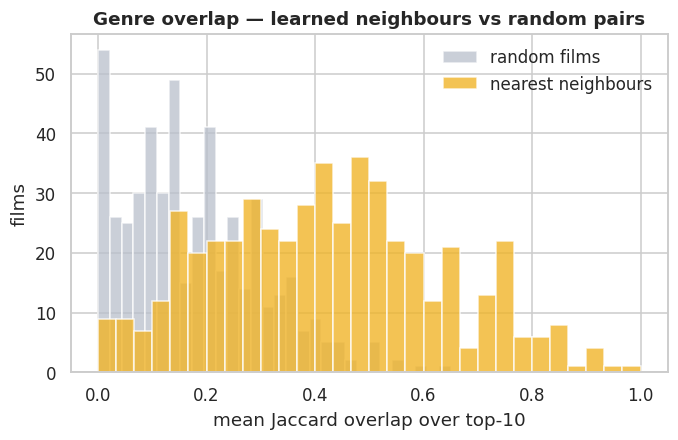

In [33]:
# Do similar embeddings mean similar films? Audit with genre labels the model never saw.
genre_sets = (movies.set_index("MovieID").loc[movie_ids, "Genres"]
              .str.split("|").apply(set).tolist())
audit_rng = np.random.default_rng(SEED)
sample = audit_rng.choice(np.flatnonzero(train_support >= 50), 500, replace=False)

def jaccard(a, b):
    union = a | b
    return len(a & b) / len(union) if union else 0.0

neighbour_scores, random_scores = [], []
for i in sample:
    nearest = np.argsort(-similarity[i])[:TOP_K]
    neighbour_scores.append(np.mean([jaccard(genre_sets[i], genre_sets[j]) for j in nearest]))
    random_scores.append(np.mean([jaccard(genre_sets[i], genre_sets[j])
                                  for j in audit_rng.choice(N_MOVIES, TOP_K, replace=False)]))

genre_coherence = {"neighbours": round(float(np.mean(neighbour_scores)), 4),
                   "random": round(float(np.mean(random_scores)), 4)}
print(f"Mean genre Jaccard overlap with the top-{TOP_K} nearest films: {genre_coherence['neighbours']}")
print(f"Same statistic for {TOP_K} random films:                        {genre_coherence['random']}")
print(f"Ratio: {genre_coherence['neighbours']/genre_coherence['random']:.1f}x")

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(random_scores, bins=30, alpha=0.75, label="random films", color="#b9c0cc")
ax.hist(neighbour_scores, bins=30, alpha=0.8, label="nearest neighbours", color=PALETTE[1])
ax.set(title="Genre overlap — learned neighbours vs random pairs",
       xlabel=f"mean Jaccard overlap over top-{TOP_K}", ylabel="films")
ax.legend(frameon=False)
fig.savefig(OUTPUT_DIR / "evaluation" / "genre_coherence.png")
plt.show()

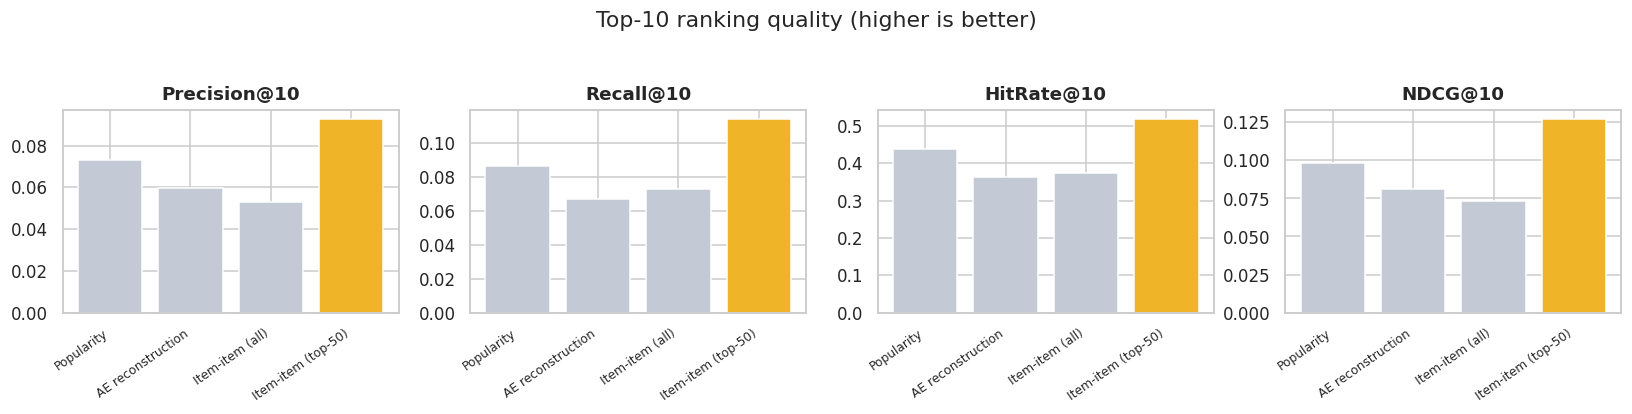

saved -> outputs/evaluation/summary.json


In [34]:
# One chart summarising the ranking comparison.
metric_cols = [c for c in ranking_results.columns if c != "scorer"]
fig, axes = plt.subplots(1, len(metric_cols), figsize=(15, 3.6))
short = ["Popularity", "AE reconstruction", "Item-item (all)", f"Item-item (top-{NEIGHBOURHOOD_K})"]
for ax, metric in zip(axes, metric_cols):
    colours = [PALETTE[1] if v == ranking_results[metric].max() else "#c3cad6"
               for v in ranking_results[metric]]
    ax.bar(range(len(ranking_results)), ranking_results[metric], color=colours)
    ax.set(title=metric, xticks=range(len(short)))
    ax.set_xticklabels(short, rotation=35, ha="right", fontsize=8)
fig.suptitle("Top-10 ranking quality (higher is better)", y=1.04)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "evaluation" / "ranking_comparison.png")
plt.show()

evaluation_summary = {
    "rating_prediction": rating_results.to_dict("records"),
    "ranking": ranking_results.to_dict("records"),
    "genre_coherence": genre_coherence,
    "settings": {"top_k": TOP_K, "relevance_threshold": RELEVANCE_THRESHOLD,
                 "neighbourhood_k": NEIGHBOURHOOD_K, "seed": SEED,
                 "test_ratings": int(len(truth)), "users_evaluated": int(evaluable)},
}
(OUTPUT_DIR / "evaluation" / "summary.json").write_text(json.dumps(evaluation_summary, indent=2))
print("saved -> outputs/evaluation/summary.json")

## 17. TMDB API Integration

MovieLens gives us titles and genres; TMDB supplies the posters, overviews and
release dates that make a recommendation feel like a recommendation. TMDB is an
**external REST API** — nothing to upload, nothing to scrape, and it plays no part
in training.

The client below is written to `src/tmdb_api.py`. What it handles:

* both credential styles (v3 API key, v4 bearer token), auto-detected;
* MovieLens' title quirks — `"American President, The (1995)"` and
  `"Postino, Il (The Postman) (1994)"` will not match TMDB as written;
* timeouts, retries with backoff, 401/403/404/429/5xx, malformed JSON;
* an on-disk cache so the same film is never requested twice;
* graceful degradation: a missing film returns a record with the MovieLens title
  intact and `tmdb_found = False`, never an exception mid-page.

In [35]:
%%writefile src/tmdb_api.py
"""
TMDB API client for enriching MovieLens recommendations with posters and metadata.

Design notes
------------
* Uses the official TMDB REST API (https://developer.themoviedb.org/docs) --
  no HTML scraping.
* Supports BOTH credential styles TMDB issues:
    - v3 API key   -> sent as the `api_key` query parameter
    - v4 read token -> sent as an `Authorization: Bearer ...` header
  The style is auto-detected from the credential itself.
* The credential is never logged, printed or embedded in a repr.
* Every network call has a timeout, retries transient failures, and returns
  `None` (rather than raising) when a movie simply cannot be found, so that a
  missing poster never breaks a recommendation table.
* Results are cached in memory and on disk, so the same movie is never
  requested twice.

MovieLens titles need normalisation before they can be searched, e.g.
    "American President, The (1995)"          -> "The American President" (1995)
    "Postino, Il (The Postman) (1994)"        -> "Il Postino" + alt "The Postman"
    "Professional, The (a.k.a. Leon: ...)"    -> "The Professional" + alt "Leon: ..."
`parse_movielens_title` handles all three patterns.
"""

from __future__ import annotations

import json
import os
import re
import time
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import requests
from requests.adapters import HTTPAdapter

try:  # urllib3 v1/v2 compatibility
    from urllib3.util.retry import Retry
except ImportError:  # pragma: no cover
    from requests.packages.urllib3.util.retry import Retry  # type: ignore

__all__ = [
    "TMDBClient",
    "TMDBError",
    "TMDBAuthError",
    "parse_movielens_title",
    "get_poster_url",
    "IMAGE_BASE_URL",
]

BASE_URL = "https://api.themoviedb.org/3"
IMAGE_BASE_URL = "https://image.tmdb.org/t/p"

# Leading articles that MovieLens moves to the end of a title.
_ARTICLES = {
    "the", "a", "an",
    "la", "le", "les", "l'", "un", "une",
    "il", "lo", "gli", "i",
    "el", "los", "las",
    "der", "die", "das", "ein", "eine",
    "de", "het", "een",
    "os", "as", "o",
}


class TMDBError(RuntimeError):
    """Raised when TMDB returns an unexpected, non-recoverable error."""


class TMDBAuthError(TMDBError):
    """Raised when the credential is missing, malformed or rejected (401/403)."""


# --------------------------------------------------------------------------- #
# Title helpers                                                                #
# --------------------------------------------------------------------------- #
def _uninvert_article(title: str) -> str:
    """'American President, The' -> 'The American President'."""
    if "," not in title:
        return title
    head, _, tail = title.rpartition(",")
    candidate = tail.strip()
    if candidate.lower() in _ARTICLES:
        joiner = "" if candidate.endswith("'") else " "
        return f"{candidate}{joiner}{head.strip()}"
    return title


def parse_movielens_title(raw_title: str) -> Tuple[str, Optional[int], List[str]]:
    """
    Split a MovieLens title into (clean_title, year, alternate_titles).

    >>> parse_movielens_title("Postino, Il (The Postman) (1994)")
    ('Il Postino', 1994, ['The Postman'])
    """
    if raw_title is None:
        return "", None, []

    text = str(raw_title).strip()

    # Trailing "(1994)" -> release year.
    year: Optional[int] = None
    year_match = re.search(r"\((\d{4})\)\s*$", text)
    if year_match:
        year = int(year_match.group(1))
        text = text[: year_match.start()].strip()

    # Remaining parenthetical groups are alternate / original-language titles.
    alternates: List[str] = []
    for group in re.findall(r"\(([^()]*)\)", text):
        alt = re.sub(r"^\s*a\.?k\.?a\.?\s*", "", group, flags=re.IGNORECASE).strip()
        if alt:
            alternates.append(_uninvert_article(alt))
    text = re.sub(r"\s*\([^()]*\)", "", text).strip()

    clean = _uninvert_article(text)
    # De-duplicate while preserving order.
    seen = {clean.lower()}
    unique_alts = []
    for alt in alternates:
        if alt.lower() not in seen:
            seen.add(alt.lower())
            unique_alts.append(alt)
    return clean, year, unique_alts


def get_poster_url(poster_path: Optional[str], size: str = "w500") -> Optional[str]:
    """Build a full poster URL from a TMDB `poster_path`. Returns None if absent."""
    if not poster_path:
        return None
    if str(poster_path).startswith("http"):
        return str(poster_path)
    return f"{IMAGE_BASE_URL}/{size}{poster_path}"


# --------------------------------------------------------------------------- #
# Client                                                                       #
# --------------------------------------------------------------------------- #
class TMDBClient:
    """
    Minimal, defensive TMDB client.

    Parameters
    ----------
    api_key : str, optional
        v3 API key or v4 read access token. Falls back to the TMDB_API_KEY /
        TMDB_API_TOKEN environment variables.
    cache_path : str or Path, optional
        JSON file used to persist lookups between runs. Set to None to disable.
    timeout : float
        Per-request timeout in seconds.
    language : str
        TMDB language code for metadata.
    min_interval : float
        Minimum delay between outbound requests (simple politeness throttle).
    """

    def __init__(
        self,
        api_key: Optional[str] = None,
        cache_path: Optional[os.PathLike | str] = "outputs/tmdb_cache.json",
        timeout: float = 10.0,
        language: str = "en-US",
        min_interval: float = 0.05,
        max_retries: int = 3,
    ) -> None:
        credential = api_key or os.getenv("TMDB_API_KEY") or os.getenv("TMDB_API_TOKEN")
        if not credential or not str(credential).strip():
            raise TMDBAuthError(
                "No TMDB credential found. Set TMDB_API_KEY in your environment "
                "or .env file, or pass api_key=... explicitly."
            )
        self._credential = str(credential).strip()
        # v4 read access tokens are JWTs ("eyJ..."); v3 keys are 32-char hex.
        self._is_bearer = self._credential.startswith("eyJ") or len(self._credential) > 60

        self.timeout = timeout
        self.language = language
        self.min_interval = min_interval
        self._last_request_ts = 0.0

        self.session = requests.Session()
        retry = Retry(
            total=max_retries,
            backoff_factor=0.5,
            status_forcelist=(429, 500, 502, 503, 504),
            allowed_methods=frozenset(["GET"]),
            raise_on_status=False,
        )
        adapter = HTTPAdapter(max_retries=retry)
        self.session.mount("https://", adapter)
        self.session.mount("http://", adapter)
        if self._is_bearer:
            self.session.headers.update({"Authorization": f"Bearer {self._credential}"})
        self.session.headers.update({"accept": "application/json"})

        self.cache_path = Path(cache_path) if cache_path else None
        self._cache: Dict[str, Any] = {}
        self._load_cache()

    # -- credential safety -------------------------------------------------- #
    def __repr__(self) -> str:  # never expose the credential
        mode = "bearer-token" if self._is_bearer else "api-key"
        return f"TMDBClient(auth={mode}, cache={len(self._cache)} entries)"

    __str__ = __repr__

    # -- cache -------------------------------------------------------------- #
    def _load_cache(self) -> None:
        if self.cache_path and self.cache_path.exists():
            try:
                self._cache = json.loads(self.cache_path.read_text(encoding="utf-8"))
            except (json.JSONDecodeError, OSError):
                self._cache = {}

    def save_cache(self) -> None:
        if not self.cache_path:
            return
        try:
            self.cache_path.parent.mkdir(parents=True, exist_ok=True)
            self.cache_path.write_text(json.dumps(self._cache), encoding="utf-8")
        except OSError:
            pass  # a non-writable cache must never break the app

    @property
    def cache_size(self) -> int:
        return len(self._cache)

    # -- transport ---------------------------------------------------------- #
    def _throttle(self) -> None:
        elapsed = time.time() - self._last_request_ts
        if elapsed < self.min_interval:
            time.sleep(self.min_interval - elapsed)
        self._last_request_ts = time.time()

    def _get(self, endpoint: str, params: Optional[Dict[str, Any]] = None) -> Optional[dict]:
        """GET a TMDB endpoint. Returns None for 404; raises TMDBError otherwise."""
        params = dict(params or {})
        params.setdefault("language", self.language)
        if not self._is_bearer:
            params["api_key"] = self._credential

        self._throttle()
        try:
            response = self.session.get(
                f"{BASE_URL}{endpoint}", params=params, timeout=self.timeout
            )
        except requests.exceptions.Timeout as exc:
            raise TMDBError(f"TMDB request timed out after {self.timeout}s") from exc
        except requests.exceptions.ConnectionError as exc:
            raise TMDBError("Could not reach TMDB (network/DNS unavailable)") from exc
        except requests.exceptions.RequestException as exc:
            raise TMDBError(f"TMDB request failed: {type(exc).__name__}") from exc

        if response.status_code in (401, 403):
            raise TMDBAuthError(
                "TMDB rejected the credential (HTTP "
                f"{response.status_code}). Check TMDB_API_KEY."
            )
        if response.status_code == 404:
            return None
        if response.status_code == 429:
            raise TMDBError("TMDB rate limit exceeded; retry shortly.")
        if not response.ok:
            raise TMDBError(f"TMDB returned HTTP {response.status_code}")
        try:
            return response.json()
        except ValueError as exc:
            raise TMDBError("TMDB returned a malformed JSON payload") from exc

    # -- public API --------------------------------------------------------- #
    def search_movie(
        self, title: str, year: Optional[int] = None, use_cache: bool = True
    ) -> Optional[dict]:
        """Search TMDB for a title, returning the best match (or None)."""
        if not title or not str(title).strip():
            return None
        key = f"search::{title.lower()}::{year or ''}"
        if use_cache and key in self._cache:
            return self._cache[key]

        params: Dict[str, Any] = {"query": title, "include_adult": "false"}
        if year:
            params["year"] = year
        payload = self._get("/search/movie", params) or {}
        results = payload.get("results") or []

        best: Optional[dict] = None
        if results:
            if year:  # prefer an exact release-year match
                exact = [
                    r for r in results
                    if str(r.get("release_date", ""))[:4] == str(year)
                ]
                best = exact[0] if exact else results[0]
            else:
                best = results[0]

        self._cache[key] = best
        return best

    def get_movie_details(self, tmdb_id: int, use_cache: bool = True) -> Optional[dict]:
        """Fetch full details for a TMDB movie id (None if it does not exist)."""
        if tmdb_id is None:
            return None
        key = f"details::{int(tmdb_id)}"
        if use_cache and key in self._cache:
            return self._cache[key]
        details = self._get(f"/movie/{int(tmdb_id)}")
        self._cache[key] = details
        return details

    def get_poster_url(self, poster_path: Optional[str], size: str = "w500") -> Optional[str]:
        return get_poster_url(poster_path, size=size)

    def enrich_movie(
        self, movielens_title: str, with_details: bool = True
    ) -> Dict[str, Any]:
        """
        Look up one MovieLens title and return a flat metadata dict.

        Never raises for a missing movie or a transient network problem: the
        `tmdb_found` flag and the `tmdb_error` field describe what happened, so
        callers can degrade gracefully and still show the MovieLens title.
        """
        clean, year, alternates = parse_movielens_title(movielens_title)
        record: Dict[str, Any] = {
            "Title": movielens_title,
            "Search_Title": clean,
            "Year": year,
            "TMDB_ID": None,
            "Poster_URL": None,
            "Overview": None,
            "Genres": None,
            "Release_Date": None,
            "TMDB_Rating": None,
            "TMDB_Votes": None,
            "tmdb_found": False,
            "tmdb_error": None,
        }

        cache_key = f"enrich::{str(movielens_title).lower()}::{int(with_details)}"
        if cache_key in self._cache:
            cached = self._cache[cache_key]
            if cached is not None:
                record.update(cached)
                return record

        # Try: exact title + year -> alternates + year -> exact title, no year.
        attempts: List[Tuple[str, Optional[int]]] = [(clean, year)]
        attempts += [(alt, year) for alt in alternates]
        attempts.append((clean, None))

        hit: Optional[dict] = None
        try:
            for candidate_title, candidate_year in attempts:
                hit = self.search_movie(candidate_title, candidate_year)
                if hit:
                    break
        except TMDBAuthError:
            raise  # a bad credential is a configuration error: surface it
        except TMDBError as exc:
            record["tmdb_error"] = str(exc)
            return record

        if not hit:
            self._cache[cache_key] = {"tmdb_found": False}
            return record

        record.update(
            {
                "TMDB_ID": hit.get("id"),
                "Poster_URL": get_poster_url(hit.get("poster_path")),
                "Overview": hit.get("overview") or None,
                "Release_Date": hit.get("release_date") or None,
                "TMDB_Rating": hit.get("vote_average"),
                "TMDB_Votes": hit.get("vote_count"),
                "tmdb_found": True,
            }
        )

        if with_details and hit.get("id"):
            try:
                details = self.get_movie_details(hit["id"])
            except TMDBError as exc:
                details = None
                record["tmdb_error"] = str(exc)
            if details:
                record["Genres"] = ", ".join(
                    g["name"] for g in details.get("genres", []) if g.get("name")
                ) or None
                record["Overview"] = details.get("overview") or record["Overview"]
                record["Release_Date"] = details.get("release_date") or record["Release_Date"]
                record["TMDB_Rating"] = details.get("vote_average", record["TMDB_Rating"])
                record["TMDB_Votes"] = details.get("vote_count", record["TMDB_Votes"])
                record["Poster_URL"] = (
                    get_poster_url(details.get("poster_path")) or record["Poster_URL"]
                )

        self._cache[cache_key] = {k: record[k] for k in record if k != "Title"}
        return record

    def enrich_dataframe(self, df, title_column: str = "Title", with_details: bool = True):
        """
        Enrich a recommendations DataFrame in place-ish (returns a new DataFrame).
        Requires pandas; imported lazily so the module stays import-light.
        """
        import pandas as pd

        rows = [self.enrich_movie(t, with_details=with_details) for t in df[title_column]]
        meta = pd.DataFrame(rows).drop(columns=["Title"])
        out = pd.concat([df.reset_index(drop=True), meta], axis=1)
        self.save_cache()
        return out

Overwriting src/tmdb_api.py


### Credentials — never hard-coded, never printed

Resolution order: existing environment variable → `.env` file → interactive
prompt (`getpass`, which does not echo). The key is never written to a cell
output, and `.env` is in `.gitignore`.

Get a free key at <https://www.themoviedb.org/settings/api>. Without one the
notebook still runs end to end — the TMDB cells switch to an offline
demonstration.

In [36]:
import getpass

TMDB_API_KEY = os.getenv("TMDB_API_KEY") or os.getenv("TMDB_API_TOKEN")

if not TMDB_API_KEY:
    try:
        from dotenv import load_dotenv
        load_dotenv()
        TMDB_API_KEY = os.getenv("TMDB_API_KEY") or os.getenv("TMDB_API_TOKEN")
    except ImportError:
        pass

if not TMDB_API_KEY and PROMPT_FOR_TMDB:
    try:
        entered = getpass.getpass("TMDB API key or v4 token (press Enter to skip): ")
        TMDB_API_KEY = entered.strip() or None
    except Exception:
        TMDB_API_KEY = None      # non-interactive run (e.g. papermill / nbconvert)

if TMDB_API_KEY:
    os.environ["TMDB_API_KEY"] = TMDB_API_KEY
    print(f"TMDB credential loaded: {len(TMDB_API_KEY)} characters, "
          f"style = {'v4 bearer token' if TMDB_API_KEY.startswith('eyJ') else 'v3 API key'}")
else:
    print("No TMDB credential — the notebook will run in offline mode.")
    print("The recommender itself does not need TMDB; only posters and overviews do.")

TMDB_ENABLED = bool(TMDB_API_KEY)

No TMDB credential — the notebook will run in offline mode.
The recommender itself does not need TMDB; only posters and overviews do.


## 18. Test the TMDB Client

Title normalisation runs regardless of credentials — it is pure string handling
and the part most likely to break silently. The live calls run only if a key was
supplied; otherwise the same code paths are exercised against a stubbed HTTP
session, so the notebook still proves the client works.

In [37]:
import src.tmdb_api as tmdb_module

importlib.reload(tmdb_module)
from src.tmdb_api import TMDBAuthError, TMDBClient, TMDBError, parse_movielens_title

tricky = ["Toy Story (1995)", "American President, The (1995)",
          "Postino, Il (The Postman) (1994)",
          "Professional, The (a.k.a. Leon: The Professional) (1994)",
          "Star Maker, The (Uomo delle stelle, L') (1995)",
          "Seven (Se7en) (1995)"]

parsed = pd.DataFrame(
    [(t, *parse_movielens_title(t)) for t in tricky],
    columns=["MovieLens title", "search title", "year", "alternate titles"],
)
display(parsed)
print(f"{(movies.Title.apply(lambda t: parse_movielens_title(t)[1] is not None)).mean():.1%} "
      "of all catalogue titles yield a release year.")

,MovieLens title,search title,year,alternate titles
0,Toy Story (1995),Toy Story,1995,[]
1,"American President, The (1995)",The American President,1995,[]
2,"Postino, Il (The Postman) (1994)",Il Postino,1994,[The Postman]
3,"Professional, The (a.k.a. Leon: The Profession...",The Professional,1994,[Leon: The Professional]
4,"Star Maker, The (Uomo delle stelle, L') (1995)",The Star Maker,1995,[L'Uomo delle stelle]
5,Seven (Se7en) (1995),Seven,1995,[Se7en]


100.0% of all catalogue titles yield a release year.


In [38]:
if TMDB_ENABLED:
    client = TMDBClient(TMDB_API_KEY, cache_path=OUTPUT_DIR / "tmdb_cache.json")
    print(f"client: {client}")                      # repr never contains the credential
    try:
        hit = client.search_movie("Toy Story", 1995)
        print(f"search  -> TMDB id {hit['id']}, released {hit['release_date']}")
        details = client.get_movie_details(hit["id"])
        print(f"details -> genres {[g['name'] for g in details['genres']]}, "
              f"rating {details['vote_average']}/10")
        print(f"poster  -> {client.get_poster_url(details['poster_path'])}")
        print(f"missing -> {client.search_movie('Zzzz No Such Film', 1899)}")
    except TMDBAuthError as exc:
        print(f"Credential rejected: {exc}")
        TMDB_ENABLED = False
    except TMDBError as exc:
        print(f"TMDB unreachable ({exc}) — continuing offline.")
        TMDB_ENABLED = False
else:
    # Offline demonstration: the real client, a stubbed transport.
    class _StubResponse:
        def __init__(self, payload, status=200):
            self._payload, self.status_code = payload, status
        ok = property(lambda self: 200 <= self.status_code < 300)
        def json(self):
            return self._payload

    class _StubSession:
        headers: dict = {}
        calls = 0
        def mount(self, *a, **k): pass
        def get(self, url, params=None, timeout=None):
            _StubSession.calls += 1
            if "/search/movie" in url:
                return _StubResponse({"results": [{
                    "id": 862, "title": "Toy Story", "release_date": "1995-11-22",
                    "poster_path": "/uXDfjJbdP4ijW5hWSBrPrlKpxab.jpg",
                    "overview": "A cowboy doll is profoundly threatened...",
                    "vote_average": 8.0, "vote_count": 18000}]})
            return _StubResponse({"id": 862, "release_date": "1995-11-22",
                                  "poster_path": "/uXDfjJbdP4ijW5hWSBrPrlKpxab.jpg",
                                  "overview": "A cowboy doll is profoundly threatened...",
                                  "vote_average": 8.0, "vote_count": 18000,
                                  "genres": [{"name": "Animation"}, {"name": "Comedy"}]})

    client = TMDBClient("stub-key-for-offline-demo", cache_path=None, min_interval=0.0)
    client.session = _StubSession()
    record = client.enrich_movie("Toy Story (1995)")
    print("Offline mode — exercising the client against a stubbed HTTP session.\n")
    print(f"  enriched: {record['Title']} -> TMDB {record['TMDB_ID']}, "
          f"genres {record['Genres']}, rating {record['TMDB_Rating']}")
    client.enrich_movie("Toy Story (1995)")
    print(f"  HTTP calls after two identical lookups: {_StubSession.calls} (cache works)")
    print(f"  repr hides the credential: {client}")

Offline mode — exercising the client against a stubbed HTTP session.

  enriched: Toy Story (1995) -> TMDB 862, genres Animation, Comedy, rating 8.0
  HTTP calls after two identical lookups: 2 (cache works)
  repr hides the credential: TMDBClient(auth=api-key, cache=3 entries)


## 19. Combine Recommendations with TMDB Metadata

The output table is what the Streamlit app renders: the collaborative-filtering
result on the left, the TMDB enrichment on the right. When TMDB has no match the
MovieLens title survives and the metadata columns are simply empty — a missing
poster must never take down a page.

In [39]:
QUERY_FILM = "Matrix, The (1999)"
base = recommend_movies(QUERY_FILM, top_n=TOP_K)

if TMDB_ENABLED:
    enriched = client.enrich_dataframe(base, title_column="Title")
    print(f"TMDB matched {int(enriched.tmdb_found.sum())} of {len(enriched)} films "
          f"({client.cache_size} entries cached)")
else:
    blank = pd.DataFrame([{ "TMDB_ID": None, "Poster_URL": None, "Overview": None,
                            "Release_Date": None, "TMDB_Rating": None, "TMDB_Votes": None,
                            "tmdb_found": False, "tmdb_error": "no credential"}
                          for _ in range(len(base))])
    enriched = pd.concat([base.reset_index(drop=True), blank], axis=1)
    print("Offline mode: the metadata columns are present but empty — this is exactly "
          "what the app receives when TMDB is unavailable, and it renders MovieLens data instead.")

columns = ["Rank", "MovieID", "Title", "Similarity", "Genres", "TMDB_ID",
           "Release_Date", "TMDB_Rating", "Poster_URL", "Overview"]
final_table = enriched.reindex(columns=[c for c in columns if c in enriched.columns])
final_table.to_csv(OUTPUT_DIR / "recommendations" / "matrix_with_tmdb.csv", index=False)
display(final_table.drop(columns=["Overview", "Poster_URL"], errors="ignore"))

Offline mode: the metadata columns are present but empty — this is exactly what the app receives when TMDB is unavailable, and it renders MovieLens data instead.


,Rank,MovieID,Title,Similarity,Genres,TMDB_ID,Release_Date,TMDB_Rating
0,1,1127,"Abyss, The (1989)",0.9254,Action|Adventure|Sci-Fi|Thriller,None,None,None
1,2,3793,X-Men (2000),0.9150,Action|Sci-Fi,None,None,None
2,3,589,Terminator 2: Judgment Day (1991),0.9012,Action|Sci-Fi|Thriller,None,None,None
3,4,1196,Star Wars: Episode V - The Empire Strikes Back...,0.8936,Action|Adventure|Drama|Sci-Fi|War,None,None,None
4,5,3578,Gladiator (2000),0.8811,Action|Drama,None,None,None
5,6,1580,Men in Black (1997),0.8805,Action|Adventure|Comedy|Sci-Fi,None,None,None
6,7,2916,Total Recall (1990),0.8743,Action|Adventure|Sci-Fi|Thriller,None,None,None
7,8,1210,Star Wars: Episode VI - Return of the Jedi (1983),0.8644,Action|Adventure|Romance|Sci-Fi|War,None,None,None
8,9,1527,"Fifth Element, The (1997)",0.8603,Action|Sci-Fi,None,None,None
9,10,592,Batman (1989),0.8528,Action|Adventure|Crime|Drama,None,None,None


In [40]:
# Render the enriched result the way the Streamlit app will.
from IPython.display import HTML

def poster_gallery(frame, limit=5):
    cards = []
    for _, r in frame.head(limit).iterrows():
        poster = r.get("Poster_URL") or "https://placehold.co/200x300/1b2130/64748b?text=No+poster"
        year = str(r.get("Release_Date") or "")[:4]
        rating = f"TMDB {r['TMDB_Rating']:.1f}" if pd.notna(r.get("TMDB_Rating")) else ""
        cards.append(
            f"<div style='width:150px;margin-right:14px;font-family:sans-serif'>"
            f"<img src='{poster}' width='150' style='border-radius:6px'>"
            f"<div style='font-size:12px;font-weight:600;margin-top:6px'>{r['Title']}</div>"
            f"<div style='font-size:11px;color:#666'>cos {r['Similarity']:.3f} {year} {rating}</div>"
            f"</div>")
    return HTML(f"<div style='display:flex'>{''.join(cards)}</div>")

print(f"Top {min(5, len(final_table))} recommendations for {QUERY_FILM}:")
display(poster_gallery(final_table))

Top 5 recommendations for Matrix, The (1999):


## 20. Save Model Artifacts

Everything the Streamlit app needs, and nothing it does not. The app loads the
embeddings and the mapping; it never touches the training data and never builds
a model.

```
models/autoencoder.keras       full trained model (reloadable, re-trainable)
models/encoder.keras           input -> latent half, regenerates embeddings
models/movie_embeddings.npy    (3706, 128) float32
models/movie_id_mapping.pkl    catalogue + MovieID<->index dicts + metadata
```

In [41]:
autoencoder.save(MODEL_PATH)
encoder.save(MODELS_DIR / "encoder.keras")
np.save(MODELS_DIR / "movie_embeddings.npy", movie_embeddings)

mapping = {
    "catalog": catalog,
    "movie_to_index": movie_to_index,
    "index_to_movie": index_to_movie,
    "user_to_index": user_to_index,
    "movie_ids": movie_ids,
    "metadata": {
        "created": pd.Timestamp.now().isoformat(timespec="seconds"),
        "dataset": "MovieLens 1M",
        "n_movies": int(N_MOVIES), "n_users": int(N_USERS),
        "n_ratings": int(len(ratings)),
        "latent_dim": int(LATENT_DIM), "hidden_dims": list(HIDDEN_DIMS),
        "seed": SEED, "epochs_trained": len(history["loss"]),
        "best_epoch": best_epoch,
        "val_masked_rmse": float(min(history["val_masked_rmse"])),
        "test_rmse": float(ae_rmse),
        "neighbourhood_k": NEIGHBOURHOOD_K, "min_support": MIN_SUPPORT,
    },
}
with open(MODELS_DIR / "movie_id_mapping.pkl", "wb") as fh:
    pickle.dump(mapping, fh)

for path in sorted(MODELS_DIR.iterdir()):
    print(f"  {path.name:<28} {path.stat().st_size/1e6:>8.2f} MB")

  autoencoder.keras               78.30 MB
  encoder.keras                   13.05 MB
  movie_embeddings.npy             1.90 MB
  movie_id_mapping.pkl             0.34 MB
  training_history.json            0.00 MB


In [42]:
# Reload from disk exactly as the Streamlit app does, and verify.
reloaded_model = keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM_OBJECTS)
reloaded_embeddings = np.load(MODELS_DIR / "movie_embeddings.npy")
with open(MODELS_DIR / "movie_id_mapping.pkl", "rb") as fh:
    reloaded_mapping = pickle.load(fh)

assert reloaded_embeddings.shape == movie_embeddings.shape
assert np.allclose(reloaded_embeddings, movie_embeddings)
assert len(reloaded_mapping["catalog"]) == reloaded_embeddings.shape[0]
assert reloaded_mapping["movie_to_index"][int(reloaded_mapping["catalog"].MovieID.iloc[0])] == 0

probe = reloaded_model.predict(X_train[:1], verbose=0)
assert np.allclose(probe, autoencoder.predict(X_train[:1], verbose=0), atol=1e-5)

reloaded_recommender = MovieRecommender.load(MODELS_DIR, default_min_support=MIN_SUPPORT)
round_trip = reloaded_recommender.recommend_movies("Toy Story (1995)", top_n=5)
assert round_trip.Title.tolist() == recommend_movies("Toy Story (1995)", top_n=5).Title.tolist()

print("Artifacts reload correctly and reproduce identical recommendations:\n")
display(round_trip[["Rank", "Title", "Similarity", "Genres"]])

Artifacts reload correctly and reproduce identical recommendations:



,Rank,Title,Similarity,Genres
0,1,Toy Story 2 (1999),0.9808,Animation|Children's|Comedy
1,2,Aladdin (1992),0.9579,Animation|Children's|Comedy|Musical
2,3,"Bug's Life, A (1998)",0.9441,Animation|Children's|Comedy
3,4,"Lion King, The (1994)",0.9070,Animation|Children's|Musical
4,5,Who Framed Roger Rabbit? (1988),0.8914,Adventure|Animation|Film-Noir


### Optional: download the artifacts from Colab

Colab's filesystem is temporary. Run the cell below to pull a zip of everything
you need for the Streamlit app onto your machine.

In [43]:
if IN_COLAB:
    import shutil
    shutil.make_archive("cinelatent_artifacts", "zip", ".", "models")
    from google.colab import files
    files.download("cinelatent_artifacts.zip")
    # Individual files instead:
    #   files.download("models/movie_embeddings.npy")
    #   files.download("models/movie_id_mapping.pkl")
else:
    print("Not in Colab — artifacts are already on disk in ./models")

Not in Colab — artifacts are already on disk in ./models


## 21. The Streamlit Application

The app is deliberately thin: load artifacts, take a title, call the recommender,
decorate with TMDB, render. No training, no dataset, no model building — which is
why it starts in under a second.

Writing it from the notebook keeps one copy of the code in one place.

In [44]:
%%writefile app.py
"""
CineLatent -- Streamlit front-end for the MovieLens deep-autoencoder recommender.

This app is a *consumer* of artifacts. It loads:
    models/movie_embeddings.npy      (one latent vector per movie)
    models/movie_id_mapping.pkl      (MovieID <-> row index + catalogue)
and never trains anything. Run the notebook first to produce them.

    streamlit run app.py
"""

from __future__ import annotations

import os
import sys
from pathlib import Path

import pandas as pd
import streamlit as st

ROOT = Path(__file__).resolve().parent
sys.path.insert(0, str(ROOT))

from src.recommender import (  # noqa: E402
    AmbiguousTitleError,
    MovieNotFoundError,
    MovieRecommender,
    RecommenderError,
)
from src.tmdb_api import TMDBAuthError, TMDBClient, TMDBError  # noqa: E402

MODELS_DIR = Path(os.getenv("MODELS_DIR", ROOT / "models"))
POSTER_FALLBACK = "https://placehold.co/500x750/1b2130/64748b?text=No+poster"

st.set_page_config(
    page_title="CineLatent — movie recommendations",
    page_icon="🎞️",
    layout="wide",
    initial_sidebar_state="expanded",
)

# --------------------------------------------------------------------------- #
# Styling: projection-booth palette, condensed display type, ticket-stub meter #
# --------------------------------------------------------------------------- #
st.markdown(
    """
    <link rel="preconnect" href="https://fonts.googleapis.com">
    <link href="https://fonts.googleapis.com/css2?family=Barlow+Condensed:wght@500;600&family=Inter:wght@400;500&family=IBM+Plex+Mono:wght@500&display=swap" rel="stylesheet">
    <style>
      :root{
        --ink:#0f141f; --slate:#1b2130; --line:#2b3547;
        --amber:#f0b429; --mist:#c8d0dd; --muted:#7d8798;
      }
      .stApp { background: var(--ink); }
      h1,h2,h3, .cl-title { font-family:'Barlow Condensed',sans-serif; letter-spacing:.4px; }
      html, body, [class*="css"] { font-family:'Inter',sans-serif; }
      .cl-head{ border-bottom:1px solid var(--line); padding-bottom:.6rem; margin-bottom:1.2rem; }
      .cl-head h1{ color:#f5f7fa; font-size:2.35rem; margin:0; font-weight:600; }
      .cl-head p{ color:var(--muted); margin:.25rem 0 0; font-size:.92rem; }
      .cl-card{
        background:var(--slate); border:1px solid var(--line); border-radius:10px;
        padding:.65rem .7rem .8rem; height:100%;
      }
      .cl-card img{ border-radius:6px; width:100%; display:block; }
      .cl-name{ font-family:'Barlow Condensed',sans-serif; font-size:1.12rem; font-weight:600;
                color:#f5f7fa; margin:.55rem 0 .15rem; line-height:1.15; }
      .cl-meta{ color:var(--muted); font-size:.76rem; margin-bottom:.4rem; }
      .cl-chip{ display:inline-block; border:1px solid var(--line); color:var(--mist);
                border-radius:999px; padding:.05rem .45rem; font-size:.68rem; margin:0 .2rem .2rem 0; }
      /* signature element: the similarity readout as a perforated ticket stub */
      .cl-stub{
        display:flex; align-items:center; gap:.5rem; margin-top:.5rem;
        border-top:1px dashed var(--line); padding-top:.45rem;
      }
      .cl-stub .num{ font-family:'IBM Plex Mono',monospace; font-size:.74rem; color:var(--amber); }
      .cl-bar{ flex:1; height:4px; background:#121826; border-radius:2px; overflow:hidden; }
      .cl-bar span{ display:block; height:100%; background:var(--amber); }
      .cl-rank{ font-family:'IBM Plex Mono',monospace; color:var(--muted); font-size:.7rem; }
      @media (prefers-reduced-motion: no-preference){
        .cl-card{ transition: border-color .18s ease; }
        .cl-card:hover{ border-color:var(--amber); }
      }
    </style>
    """,
    unsafe_allow_html=True,
)


# --------------------------------------------------------------------------- #
# Cached resources                                                             #
# --------------------------------------------------------------------------- #
@st.cache_resource(show_spinner="Loading movie embeddings…")
def load_recommender(models_dir: str) -> MovieRecommender:
    return MovieRecommender.load(models_dir)


@st.cache_resource(show_spinner=False)
def load_tmdb_client() -> TMDBClient | None:
    """Read the credential from Streamlit secrets, the environment, or .env."""
    credential = None
    try:
        credential = st.secrets.get("TMDB_API_KEY")  # type: ignore[attr-defined]
    except Exception:
        credential = None
    if not credential:
        try:
            from dotenv import load_dotenv

            load_dotenv(ROOT / ".env")
        except ImportError:
            pass
        credential = os.getenv("TMDB_API_KEY") or os.getenv("TMDB_API_TOKEN")
    if not credential:
        return None
    try:
        return TMDBClient(credential, cache_path=ROOT / "outputs" / "tmdb_cache.json")
    except TMDBAuthError:
        return None


@st.cache_data(show_spinner=False, ttl=60 * 60 * 24)
def fetch_metadata(title: str) -> dict:
    """One TMDB lookup per title, cached for a day. Never raises."""
    client = load_tmdb_client()
    if client is None:
        return {"tmdb_found": False, "tmdb_error": "no-credential"}
    try:
        record = client.enrich_movie(title)
        client.save_cache()
        return record
    except TMDBAuthError:
        return {"tmdb_found": False, "tmdb_error": "auth"}
    except TMDBError as exc:
        return {"tmdb_found": False, "tmdb_error": str(exc)}


# --------------------------------------------------------------------------- #
# Rendering                                                                    #
# --------------------------------------------------------------------------- #
def render_card(row: pd.Series, meta: dict, use_tmdb: bool) -> None:
    poster = meta.get("Poster_URL") if use_tmdb else None
    genres = meta.get("Genres") if (use_tmdb and meta.get("Genres")) else str(row["Genres"]).replace("|", ", ")
    year = str(meta.get("Release_Date") or "")[:4]
    rating = meta.get("TMDB_Rating")

    bits = []
    if year:
        bits.append(year)
    if rating:
        bits.append(f"TMDB {float(rating):.1f}/10")
    bits.append(f"{int(row['RatingCount'])} MovieLens ratings")

    chips = "".join(
        f"<span class='cl-chip'>{g.strip()}</span>" for g in str(genres).split(",") if g.strip()
    )
    pct = max(0.0, min(1.0, float(row["Similarity"]))) * 100

    st.markdown(
        f"""
        <div class="cl-card">
          <img src="{poster or POSTER_FALLBACK}" alt="Poster for {row['Title']}">
          <div class="cl-name">{row['Title']}</div>
          <div class="cl-meta">{' · '.join(bits)}</div>
          <div>{chips}</div>
          <div class="cl-stub">
            <span class="cl-rank">#{int(row['Rank']):02d}</span>
            <span class="cl-bar"><span style="width:{pct:.0f}%"></span></span>
            <span class="num">{float(row['Similarity']):.3f}</span>
          </div>
        </div>
        """,
        unsafe_allow_html=True,
    )
    overview = meta.get("Overview")
    if use_tmdb and overview:
        with st.expander("Overview"):
            st.write(overview)


def render_results(recs: pd.DataFrame, use_tmdb: bool, columns: int = 5) -> None:
    metas = {}
    if use_tmdb:
        progress = st.progress(0.0, text="Fetching posters from TMDB…")
        for i, title in enumerate(recs["Title"], start=1):
            metas[title] = fetch_metadata(title)
            progress.progress(i / len(recs), text=f"Fetching posters from TMDB… ({i}/{len(recs)})")
        progress.empty()
        failed = [t for t, m in metas.items() if not m.get("tmdb_found")]
        if failed and len(failed) == len(recs):
            st.warning(
                "TMDB returned nothing for these titles — showing MovieLens metadata instead."
            )
        elif failed:
            st.caption(f"No TMDB match for: {', '.join(failed)} — MovieLens data shown for those.")

    for start in range(0, len(recs), columns):
        chunk = recs.iloc[start : start + columns]
        for col, (_, row) in zip(st.columns(columns), chunk.iterrows()):
            with col:
                render_card(row, metas.get(row["Title"], {}), use_tmdb)


# --------------------------------------------------------------------------- #
# App                                                                          #
# --------------------------------------------------------------------------- #
st.markdown(
    """
    <div class="cl-head">
      <h1>CineLatent</h1>
      <p>Neighbours in the latent space of a deep autoencoder trained on 1,000,209 MovieLens ratings.</p>
    </div>
    """,
    unsafe_allow_html=True,
)

try:
    rec = load_recommender(str(MODELS_DIR))
except FileNotFoundError as exc:
    st.error(str(exc))
    st.info(
        "Open `notebooks/movie_recommender.ipynb`, run it top to bottom, and the "
        "`models/` folder will be created. Then reload this page."
    )
    st.stop()
except Exception as exc:  # corrupt or mismatched artifacts
    st.error(f"Could not load the saved artifacts: {exc}")
    st.stop()

tmdb_client = load_tmdb_client()

with st.sidebar:
    st.subheader("Settings")
    top_n = st.slider("How many recommendations", 5, 20, 10, step=5)
    min_support = st.slider(
        "Minimum ratings per recommended movie",
        0, 200, 10, step=10,
        help="Movies rated by only a handful of users have noisy embeddings. "
             "Raise this for safer, more mainstream suggestions.",
    )
    want_tmdb = st.toggle("Show posters and TMDB metadata", value=tmdb_client is not None)
    if want_tmdb and tmdb_client is None:
        st.warning(
            "No TMDB credential found. Add `TMDB_API_KEY` to `.env` or to "
            "`.streamlit/secrets.toml`, then reload.",
            icon="🔑",
        )
        want_tmdb = False
    st.divider()
    st.caption(
        f"{len(rec.catalog):,} movies · {rec.embeddings.shape[1]}-dimensional embeddings\n\n"
        "Similarity is cosine distance between latent vectors learned from rating "
        "patterns alone — no plot, cast or genre information is used."
    )

tab_similar, tab_profile = st.tabs(["Similar to one movie", "Blend a few favourites"])

with tab_similar:
    default_idx = (
        rec.titles.index("Toy Story (1995)") if "Toy Story (1995)" in rec.titles else 0
    )
    choice = st.selectbox(
        "Pick a movie you liked", rec.titles, index=default_idx,
        help="Type to search the MovieLens catalogue.",
    )
    if st.button("Recommend", type="primary", key="btn_similar"):
        try:
            recs = rec.recommend_movies(choice, top_n=top_n, min_support=min_support)
        except (MovieNotFoundError, AmbiguousTitleError, RecommenderError) as exc:
            st.error(str(exc))
        else:
            note = recs.attrs.get("low_support_query")
            if note:
                st.info(note)
            st.caption(
                f"Closest neighbours to **{recs.attrs['query_title']}** "
                f"among {recs.attrs['n_candidates']:,} eligible movies."
            )
            render_results(recs, want_tmdb)

with tab_profile:
    picks = st.multiselect(
        "Pick two or more movies you liked", rec.titles,
        default=[t for t in ["Alien (1979)", "Blade Runner (1982)"] if t in rec.titles],
    )
    if st.button("Blend these", type="primary", key="btn_profile"):
        if len(picks) < 1:
            st.error("Choose at least one movie first.")
        else:
            try:
                recs = rec.recommend_from_profile(picks, top_n=top_n, min_support=min_support)
            except (MovieNotFoundError, RecommenderError) as exc:
                st.error(str(exc))
            else:
                st.caption(f"Averaged latent neighbours of {len(picks)} selected films.")
                render_results(recs, want_tmdb)

Overwriting app.py


Run it from a terminal in the project folder:

```bash
streamlit run app.py
```

In Colab there is no browser to open, so expose the port with a tunnel:

```python
!pip install -q streamlit pyngrok
!streamlit run app.py --server.port 8501 &>/dev/null &
from pyngrok import ngrok
print(ngrok.connect(8501))
```

## 22. Final Project Summary

In [45]:
best_ranker = ranking_results.loc[ranking_results[f"NDCG@{TOP_K}"].idxmax()]
popularity_row = ranking_results.loc[ranking_results.scorer == "Popularity baseline"].iloc[0]

print("=" * 72)
print("CineLatent — deep autoencoder recommender on MovieLens 1M".center(72))
print("=" * 72)
print(f"""
DATA
  ratings                {len(ratings):,}
  users / movies         {N_USERS:,} / {N_MOVIES:,}
  matrix sparsity        {sparsity:.2%} empty
  split (per user)       {len(train_df):,} train / {len(val_df):,} val / {len(test_df):,} test

MODEL
  architecture           {N_USERS} -> {' -> '.join(str(h) for h in HIDDEN_DIMS)} -> {LATENT_DIM} -> {' -> '.join(str(h) for h in reversed(HIDDEN_DIMS))} -> {N_USERS}
  parameters             {autoencoder.count_params():,}
  loss                   masked MSE (observed cells only)
  epochs                 {len(history['loss'])} (best at {best_epoch}, early stopping)
  validation RMSE        {min(history['val_masked_rmse']):.4f} stars

RATING PREDICTION (test set, {len(truth):,} held-out ratings)
  autoencoder            RMSE {ae_rmse:.4f} | MAE {rating_results.loc[rating_results.model=='Deep autoencoder','MAE'].iloc[0]:.4f}
  best baseline          RMSE {best_base:.4f}
  improvement            {(best_base - ae_rmse)/best_base:.1%} lower RMSE

TOP-{TOP_K} RANKING ({evaluable:,} users with a relevant test item)
  best scorer            {best_ranker.scorer}
                         P@{TOP_K} {best_ranker[f'Precision@{TOP_K}']:.4f} | R@{TOP_K} {best_ranker[f'Recall@{TOP_K}']:.4f} | HR@{TOP_K} {best_ranker[f'HitRate@{TOP_K}']:.4f} | NDCG@{TOP_K} {best_ranker[f'NDCG@{TOP_K}']:.4f}
  popularity baseline    P@{TOP_K} {popularity_row[f'Precision@{TOP_K}']:.4f} | R@{TOP_K} {popularity_row[f'Recall@{TOP_K}']:.4f} | HR@{TOP_K} {popularity_row[f'HitRate@{TOP_K}']:.4f} | NDCG@{TOP_K} {popularity_row[f'NDCG@{TOP_K}']:.4f}

EMBEDDING SANITY CHECK
  genre overlap          {genre_coherence['neighbours']:.3f} for learned neighbours vs {genre_coherence['random']:.3f} random
                         (genres were never shown to the model)

ARTIFACTS
  models/                autoencoder.keras, encoder.keras, movie_embeddings.npy,
                         movie_id_mapping.pkl
  outputs/               eda/ (11 figures), evaluation/ (metrics + charts),
                         recommendations/ (example Top-10 tables)
  src/                   recommender.py, tmdb_api.py
  app.py                 Streamlit interface

NEXT STEP
  streamlit run app.py
""")
print("=" * 72)

       CineLatent — deep autoencoder recommender on MovieLens 1M        

DATA
  ratings                1,000,209
  users / movies         6,040 / 3,706
  matrix sparsity        95.53% empty
  split (per user)       802,553 train / 100,273 val / 97,383 test

MODEL
  architecture           6040 -> 512 -> 256 -> 128 -> 256 -> 512 -> 6040
  parameters             6,520,344
  loss                   masked MSE (observed cells only)
  epochs                 30 (best at 20, early stopping)
  validation RMSE        0.8695 stars

RATING PREDICTION (test set, 97,383 held-out ratings)
  autoencoder            RMSE 0.8604 | MAE 0.6720
  best baseline          RMSE 0.9321
  improvement            7.7% lower RMSE

TOP-10 RANKING (5,862 users with a relevant test item)
  best scorer            Embedding item-item (top-50 neighbours)
                         P@10 0.0927 | R@10 0.1137 | HR@10 0.5179 | NDCG@10 0.1271
  popularity baseline    P@10 0.0733 | R@10 0.0861 | HR@10 0.4369 | NDCG@10 0.0986

EMB

### Honest limitations

* **Cold start.** A film with no ratings gets no embedding, and a brand-new user
  has no profile. This architecture cannot solve either; a content-based signal
  (TMDB overviews, cast) or a hybrid model would be the next step.
* **Temporal cohorts.** Half of MovieLens 1M was rated in a few months of 2000, so
  the model partly learns "watched in the same period" rather than "liked by the
  same taste". It is visible in the recommendations — contemporaneous releases
  cluster together more than their content warrants.
* **Popularity bias.** Ratings concentrate on blockbusters, and the recommender
  inherits that. `min_support` mitigates the opposite failure (noise from
  near-unrated films) but does not remove the bias.
* **Offline metrics only.** Precision@10 measures agreement with what users
  happened to rate later, not what they would have enjoyed had it been shown.
  Only an online A/B test measures that.
* **One random seed.** Every number here comes from a single training run with
  `SEED = 42`. Reported differences between scorers are large enough to be
  meaningful; small differences would need repeated runs to be trusted.